This notebook uses a simple model to test if an ANN is capable of learning postion from Frequency, ITD, and ILD information

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import keras
import pandas as pd 
import scipy.io as sio

import librosa
import soundfile as sf

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from itertools import product
from IPython.display import clear_output
import importlib


I0000 00:00:1786038595.361284 1492636 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786038595.386853 1492636 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786038596.028833 1492636 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [5]:
print(tf.__version__)

2.21.0


In [6]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


W0000 00:00:1785870334.664443  262836 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


# Load & Plot HRTF Data

In [7]:
import seaborn as sns
sns.set_style("whitegrid")

In [23]:
#Load HRTF data
!wget https://www.dropbox.com/s/tvbv9hxwu2ydtbz/HRTF880ILDIPDABL.mat?dl=0

#Filename
filename = 'HRTF880ILDIPDABL.mat?dl=0'

#The data are .mat files. Use scipy to load a file:
mat = sio.loadmat(filename, squeeze_me=True)

--2026-07-28 13:11:54--  https://www.dropbox.com/s/tvbv9hxwu2ydtbz/HRTF880ILDIPDABL.mat?dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.2.18, 2620:100:6017:18::a27d:212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.2.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/td7uc6tt9j5utwuxm601z/HRTF880ILDIPDABL.mat?rlkey=skgmtjcd4i7vq2t90rlu2buj8&dl=0 [following]
--2026-07-28 13:11:54--  https://www.dropbox.com/scl/fi/td7uc6tt9j5utwuxm601z/HRTF880ILDIPDABL.mat?rlkey=skgmtjcd4i7vq2t90rlu2buj8&dl=0
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc72ed3d0bbb6ae0383002beab05.dl.dropboxusercontent.com/cd/0/inline/DFK3c89EcaHhJJsa6rhIn6TKvzyW8EuOmXim1yrUS_GVFU8SupxlOcFMVkXTuXuEfvAieVsMC2XLsU2ucRtrwWsuNI4QKKyOwjEW6qFqnrMwMp7Ns2vMxBPLVjKvmkXLE5M/file# [following]
--2026-07-28 13:11:55--  https://uc72ed3d0bbb6ae0383002beab05.dl.dropboxusercontent

In [24]:
mat

{'__header__': b'MATLAB 5.0 MAT-file, Platform: MACI64, Created on: Wed Nov 21 14:03:02 2012',
 '__version__': '1.0',
 '__globals__': [],
 'f2': array([2.95275591, 3.07086614, 3.18897638, 3.30708661, 3.42519685,
        3.54330709, 3.66141732, 3.77952756, 3.8976378 , 4.01574803,
        4.13385827, 4.2519685 , 4.37007874, 4.48818898, 4.60629921,
        4.72440945, 4.84251969, 4.96062992, 5.07874016, 5.19685039,
        5.31496063, 5.43307087, 5.5511811 , 5.66929134, 5.78740157,
        5.90551181, 6.02362205, 6.14173228, 6.25984252, 6.37795276,
        6.49606299, 6.61417323, 6.73228346, 6.8503937 , 6.96850394,
        7.08661417, 7.20472441, 7.32283465, 7.44094488, 7.55905512,
        7.67716535, 7.79527559, 7.91338583, 8.03149606, 8.1496063 ,
        8.26771654, 8.38582677, 8.50393701, 8.62204724, 8.74015748,
        8.85826772, 8.97637795]),
 'Xc': array([-90, -85, -85, -85, -80, -80, -80, -80, -80, -75, -75, -75, -75,
        -75, -75, -75, -70, -70, -70, -70, -70, -70, -70, -70, 

In [25]:
#HRTF properties
IPD = mat['IPD']
ILD = mat['ILD']
ABL = mat['ABL']

#Directions
Az = mat['Xc']
El = mat['Yc']

#Frequency
f = mat['f2']

In [26]:
IPD

array([[ 2.56969758, -3.84640715, -3.88119909, ..., -1.32872962,
        -1.47080492, -1.64011591],
       [ 2.70557322, -3.79588504,  2.26604055, ..., -1.42463703,
        -1.56779399, -1.71833284],
       [ 2.73776269, -3.70584847, -3.84998169, ..., -0.96784417,
        -1.12770559, -1.26070519],
       ...,
       [-2.36242364,  4.01582142, -2.08704706, ...,  3.2675239 ,
         3.62784749, -2.20891956],
       [-2.26092005,  4.14340538, -2.02902407, ...,  4.2335535 ,
        -1.74539249, -1.40837343],
       [-2.17845958,  4.2798604 , -2.10071216, ...,  3.92091378,
        -2.12642349, -1.85852071]], shape=(685, 52))

In [6]:
print(f'Frequency Shape: {f.shape}')
print(f'IPD Shape: {IPD.shape}')
print(f'ILD Shape: {ILD.shape}')
print(f'ABL Shape: {ABL.shape}')
print(f'Azimuth Shape: {Az.shape}')
print(f'Elevation Shape: {El.shape}')

Frequency Shape: (52,)
IPD Shape: (685, 52)
ILD Shape: (685, 52)
ABL Shape: (685, 52)
Azimuth Shape: (685,)
Elevation Shape: (685,)


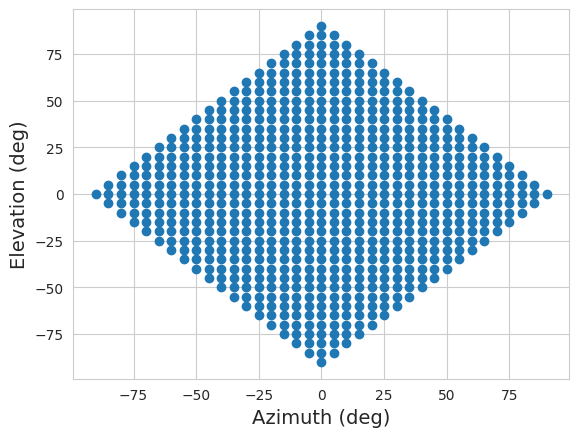

In [27]:
# Plot Azimuth vs Elevation span
plt.scatter(Az,El)
plt.xlabel('Azimuth (deg)', fontsize = 14)
plt.ylabel('Elevation (deg)', fontsize = 14)
plt.show()

Index: 0, Azimuth: -90, Elevation: 0


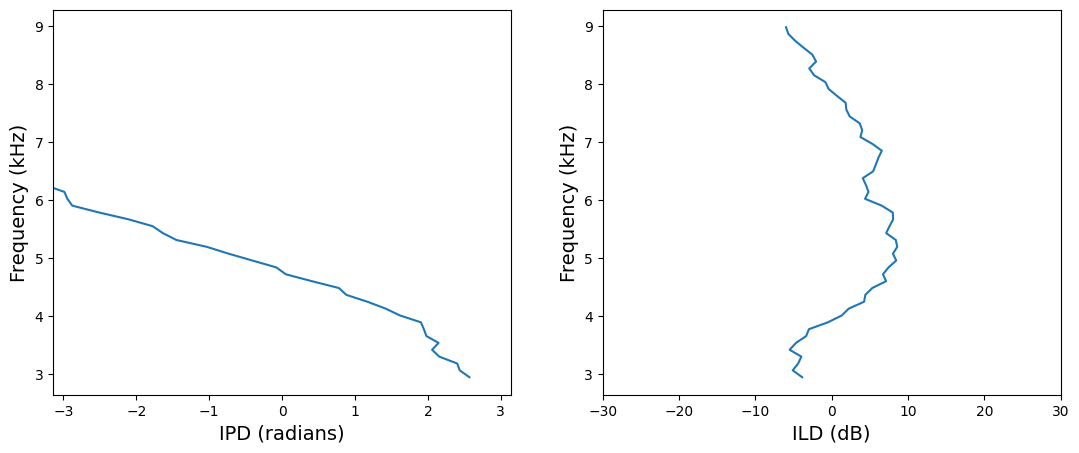

Index: 137, Azimuth: -35, Elevation: 25


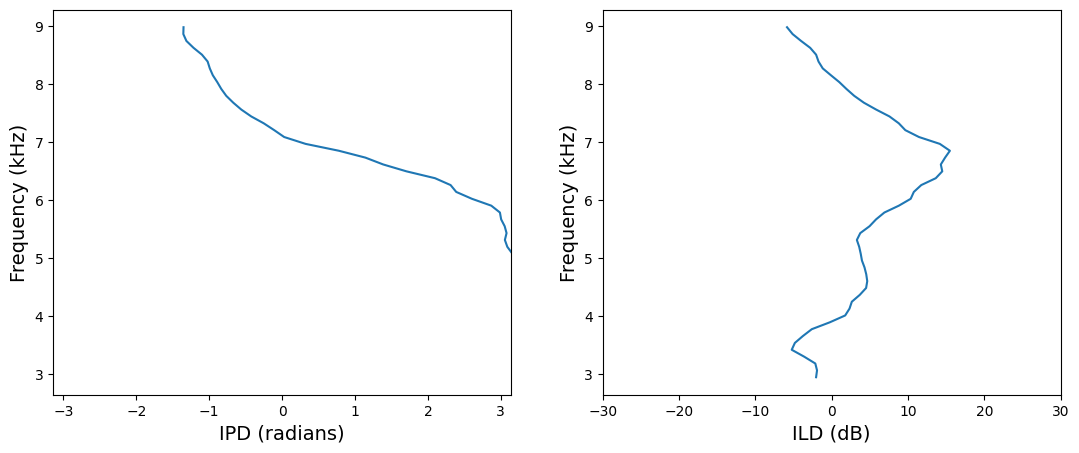

Index: 274, Azimuth: -10, Elevation: 10


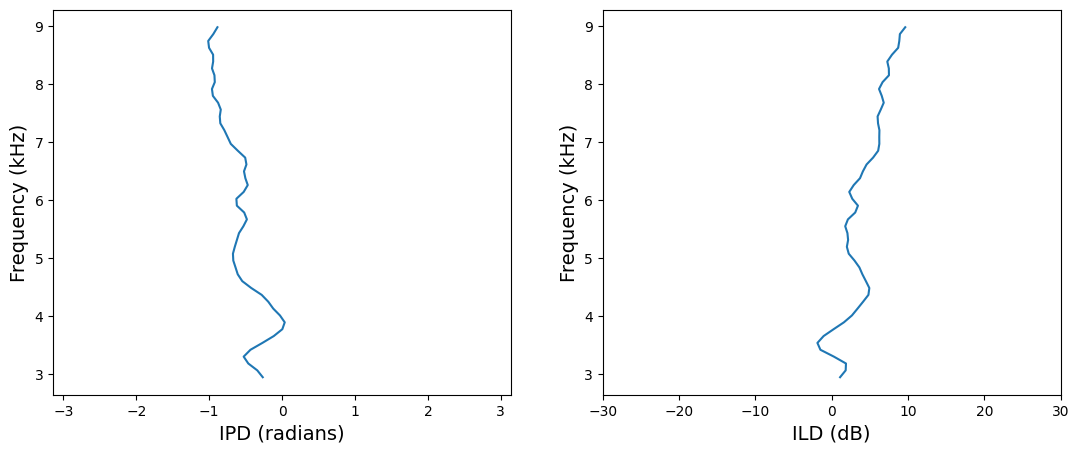

Index: 411, Azimuth: 10, Elevation: -5


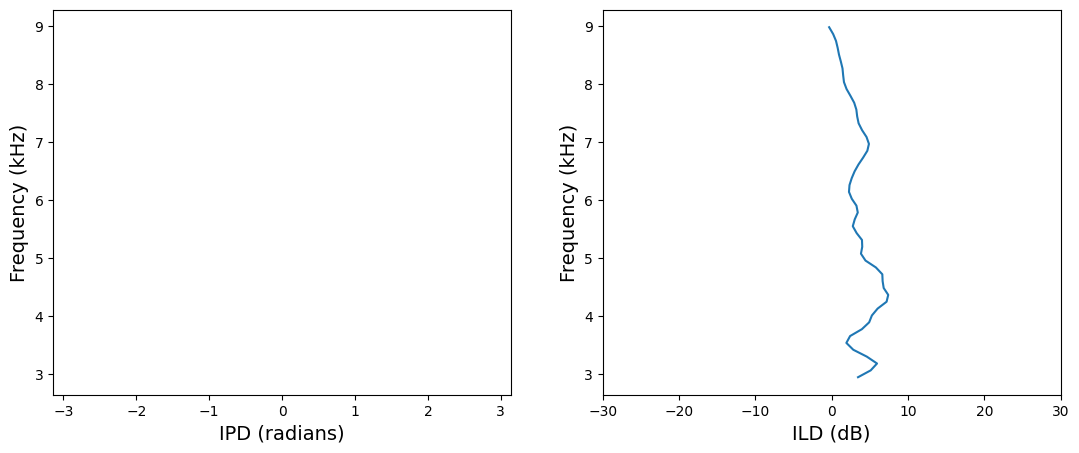

Index: 548, Azimuth: 35, Elevation: -20


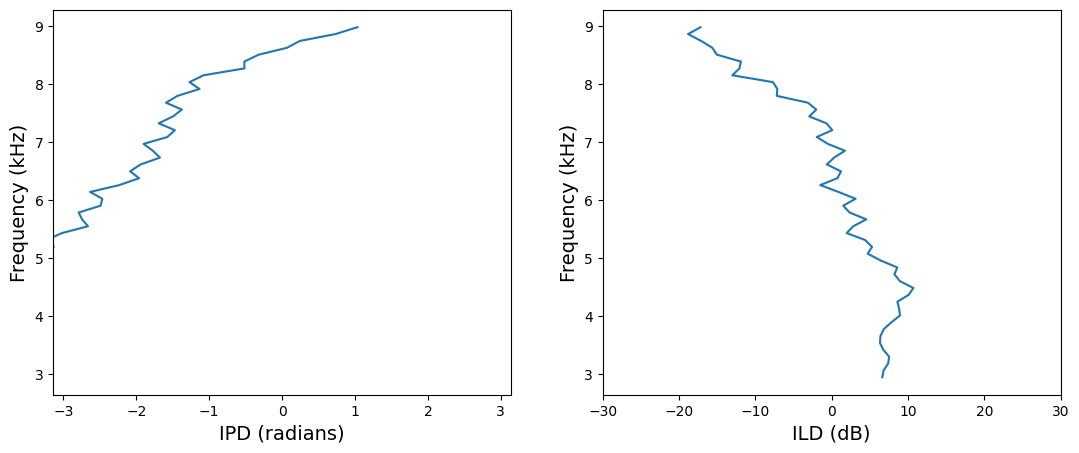

In [ ]:
#Plot IPD and ILD for selected directions
count = 5
step = len(list(zip(Az, El))) // count

for idx, (az, el) in enumerate(zip(Az, El)):
    if idx % step == 0:
        print(f"Index: {idx}, Azimuth: {az}, Elevation: {el}")
        #Find the index of this direction in the direction matrices

        direction_index = np.where((Az == az) & (El == el))[0][0]

        #Plot
        plt.subplots(1,2, figsize = (13,5))

        plt.subplot(1,2,1)
        plt.plot(np.unwrap(IPD[direction_index,]), f)
        plt.xlim(-np.pi, np.pi)
        plt.ylabel('Frequency (kHz)', fontsize = 14)
        plt.xlabel('IPD (radians)', fontsize = 14)

        plt.subplot(1,2,2)
        plt.plot(ILD[direction_index,], f)
        plt.xlim(-30, 30)
        plt.ylabel('Frequency (kHz)', fontsize = 14)
        plt.xlabel('ILD (dB)', fontsize = 14)
        plt.show()



In [29]:
IPD.min(), IPD.max()

(np.float64(-6.206289429710955), np.float64(6.190289788175141))

In [27]:
#Create data set of x, y for each elevation  
x_data = []
y_data = []
freq_axis = f
itd_axis = IPD[0]
ild_axis = ILD[0]

for idx, (az, el) in enumerate(zip(Az, El)):
    direction_index = np.where((Az == az) & (El == el))[0][0]

    if IPD[direction_index,].size == 0 or ILD[direction_index,].size == 0:
        print(idx)
        continue

    # print('Shape of f:', f.shape)
    # print('Shape of IPD:', IPD[direction_index,].shape)
    # print('Shape of ILD:', ILD[direction_index,].shape)

    features = np.concatenate(
                [
                    #np.stack(f, axis=0).reshape(-1),
                    np.stack(IPD[direction_index,], axis=0).reshape(-1),
                    np.stack(ILD[direction_index,], axis=0).reshape(-1),
                ]
            ).astype(np.float32)

    # print('Shape of data:', features.shape)

    x_data.append(features)
    y_data.append([az, el])

x_data = np.array(x_data)
y_data = np.array(y_data)

In [28]:
print('x_train shape:', x_data.shape, '| y_train shape:', y_data.shape)
print('freq bins:', len(freq_axis), '| min/max:', float(freq_axis[0]), float(freq_axis[-1]))
print('itd bins:', len(itd_axis), '| min/max:', float(itd_axis[0]), float(itd_axis[-1]))
print('ild bins:', len(ild_axis), '| min/max:', float(ild_axis[0]), float(ild_axis[-1]))

x_train shape: (685, 104) | y_train shape: (685, 2)
freq bins: 52 | min/max: 2.952755905511811 8.976377952755904
itd bins: 52 | min/max: 2.569697584707848 -1.6401159050335066
ild bins: 52 | min/max: -3.8638860154223647 -5.980764136390093


In [ ]:
def _plot_filtered_profiles(
    x_data,
    y_data,
    freq_axis,
    itd_axis,
    ild_axis,
    azimuth_range=(-75, -25),
    elevation_range=(-15, 15),
    max_samples=200,
    random_seed=42,
    show_individual=True,
    individual_alpha=0.08,
    n_time_steps=8,
):
    """Plot filtered frequency/ITD/ILD profiles and target locations for selected samples."""
    mask = (
        (y_data[:, 0] >= azimuth_range[0]) & (y_data[:, 0] <= azimuth_range[1]) &
        (y_data[:, 1] >= elevation_range[0]) & (y_data[:, 1] <= elevation_range[1])
    )

    selected_idx = np.where(mask)[0]
    print(f'Matching samples: {len(selected_idx)}')

    if len(selected_idx) == 0:
        print('No samples matched these ranges. Widen the filters and rerun.')
        return selected_idx

    rng = np.random.default_rng(random_seed)
    if len(selected_idx) > max_samples:
        selected_idx = rng.choice(selected_idx, size=max_samples, replace=False)

    selected_x = x_data[selected_idx]
    selected_y = y_data[selected_idx]

    n_i = len(itd_axis)
    n_l = len(ild_axis)
    per_step = n_i + n_l
    expected_len = n_time_steps * per_step
    if selected_x.shape[1] != expected_len:
        raise ValueError(
            f'Expected flattened feature length {expected_len}, got {selected_x.shape[1]}. '
            'Pass the correct n_time_steps for this dataset.'
        )

    itd_batch = selected_x
    ild_batch = selected_x

    fig, axes = plt.subplots(1, 3, figsize=(14, 9))


    if show_individual:
        for sample in itd_batch:
            axes[0, 1].plot(itd_axis, sample.mean(axis=0), color='tab:orange', alpha=individual_alpha)
    axes[0, 1].plot(itd_axis, itd_batch.mean(axis=(0, 1)), color='darkorange', linewidth=2.5, label='Mean')
    axes[0, 1].set_title('ITD Profiles (Filtered Batch)')
    axes[0, 1].set_xlabel('ITD (ms)')
    axes[0, 1].set_ylabel('Normalized Response')
    axes[0, 1].grid(alpha=0.3)
    axes[0, 1].legend()

    if show_individual:
        for sample in ild_batch:
            axes[1, 0].plot(ild_axis, sample.mean(axis=0), color='tab:green', alpha=individual_alpha)
    axes[0, 2].plot(ild_axis, ild_batch.mean(axis=(0, 1)), color='darkgreen', linewidth=2.5, label='Mean')
    axes[0, 2].set_title('ILD Profiles (Filtered Batch)')
    axes[0, 2].set_xlabel('ILD (dB)')
    axes[0, 2].set_ylabel('Normalized Response')
    axes[0, 2].grid(alpha=0.3)
    axes[0, 2].legend()

    axes[0, 3].scatter(y_data[:, 0], y_data[:, 1], s=8, c='lightgray', alpha=0.35, label='All samples')
    sc = axes[1, 1].scatter(
        selected_y[:, 0],
        selected_y[:, 1],
        s=35,
        edgecolor='black',
        linewidth=0.2,
        label='Filtered samples',
    )
    axes[1, 1].set_title('Filtered Target Locations')
    axes[1, 1].set_xlabel('Azimuth (deg)')
    axes[1, 1].set_ylabel('Elevation (deg)')
    axes[1, 1].set_xlim(-95, 95)
    axes[1, 1].set_ylim(-50, 50)
    axes[1, 1].grid(alpha=0.3)
    axes[1, 1].legend(loc='upper right')

    fig.suptitle(
        f'Filtered batch: az={azimuth_range}, el={elevation_range} | n={len(selected_idx)}',
        fontsize=13,
    )
    plt.tight_layout()
    plt.show()

    return selected_idx

In [36]:
_plot_filtered_profiles(
    x_data,
    y_data,
    freq_axis,
    itd_axis,
    ild_axis,
    azimuth_range=(-5, -5),
    elevation_range=(-5, 5),
    max_samples=200,
    random_seed=42,
    show_individual=True,
    individual_alpha=0.08,
    n_time_steps=1,
)

Matching samples: 3


ValueError: cannot reshape array of size 153 into shape (3,1,52)

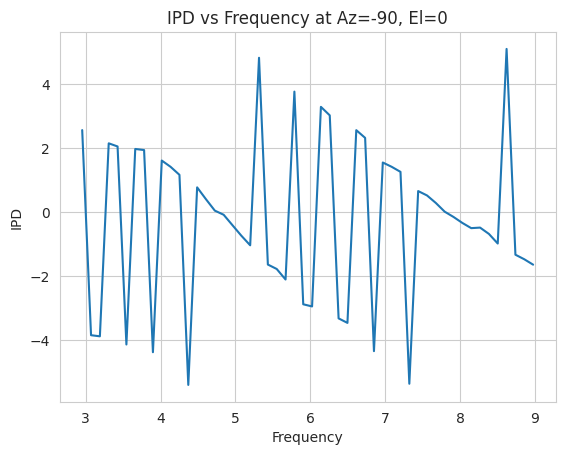

In [30]:
plt.plot(freq_axis, IPD[0])
plt.title(f'IPD vs Frequency at Az={Az[0]}, El={El[0]}')
plt.xlabel('Frequency')
plt.ylabel('IPD')
plt.show()

Matching samples: 21


/home/mrsarti/rANN/make_data.py:294: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = axes[0, 0].imshow(


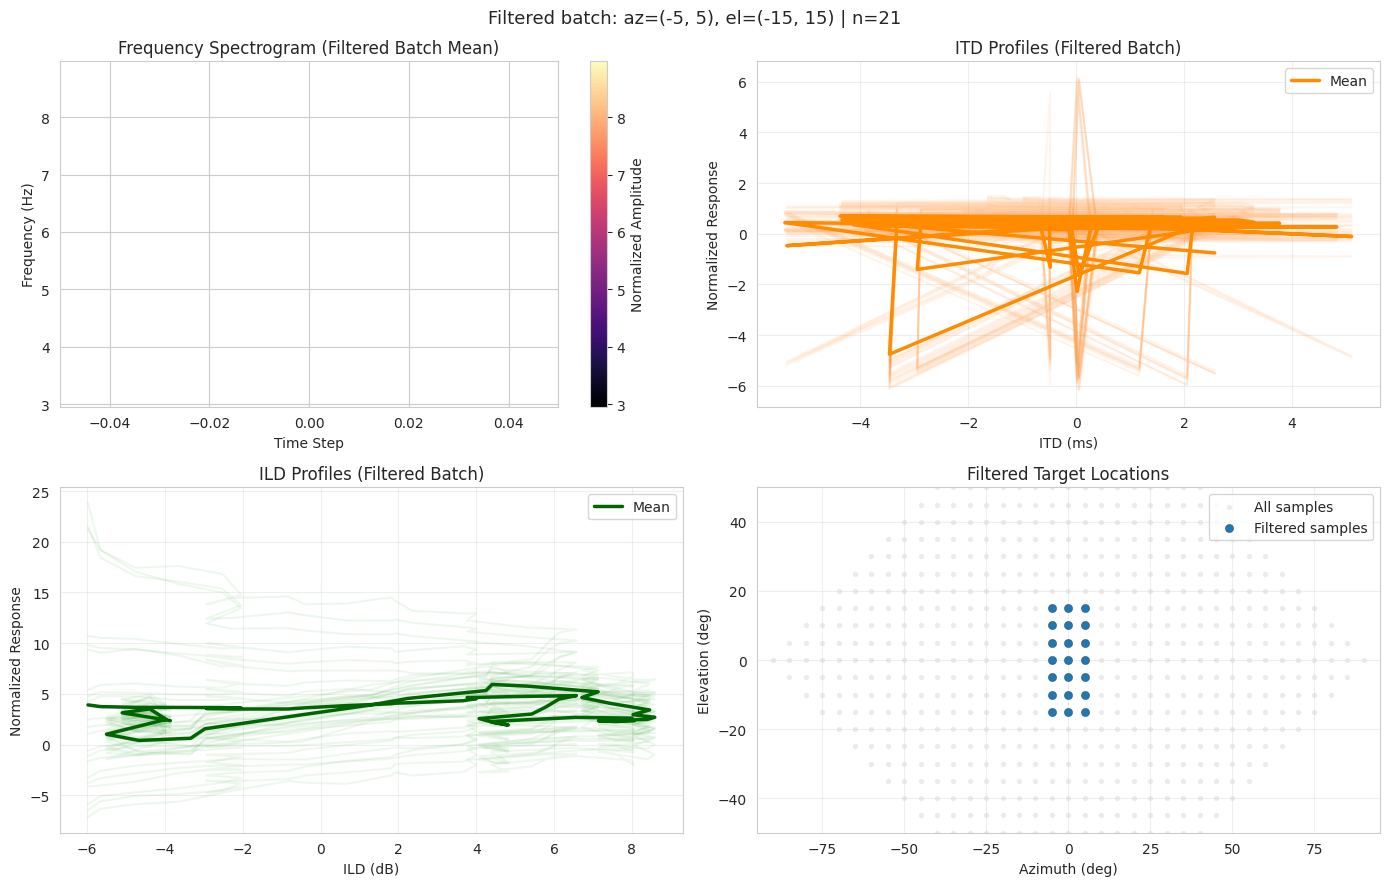

In [83]:
# Azmuth range (-5, 5)
selected_idx = plot_filtered_profiles(
    x_data,
    y_data,
    freq_axis,
    itd_axis,
    ild_axis,
    azimuth_range=(-5, 5),
    elevation_range=(-15, 15),
    n_time_steps = 1,
    max_samples=200,
    random_seed=42,
    show_individual=True,
)

# Make & Plot Data (Generated)

In [ ]:
from make_data import create_synthetic_dataset 

In [9]:
# Example: narrower ITD tuning with HWHH = 0.03 ms
x_train, y_train, freq_axis, itd_axis, ild_axis = create_synthetic_dataset(n_samples=5000, itd_hwhh=0.03, ipd_aliases=2)
print('x_train shape:', x_train.shape, '| y_train shape:', y_train.shape)
print('freq bins:', len(freq_axis), '| min/max:', float(freq_axis[0]), float(freq_axis[-1]))
print('itd bins:', len(itd_axis), ' | min/max:', float(itd_axis[0]), float(itd_axis[-1]))
print('ild bins:', len(ild_axis), ' | min/max:', float(ild_axis[0]), float(ild_axis[-1]))

x_train shape: (5000, 768) | y_train shape: (5000, 2)
freq bins: 32 | min/max: 2000.0 10000.0
itd bins: 32  | min/max: -0.18000000715255737 0.18000000715255737
ild bins: 32  | min/max: -30.0 30.0


In [7]:
from make_data import plot_filtered_profiles

Matching samples: 94


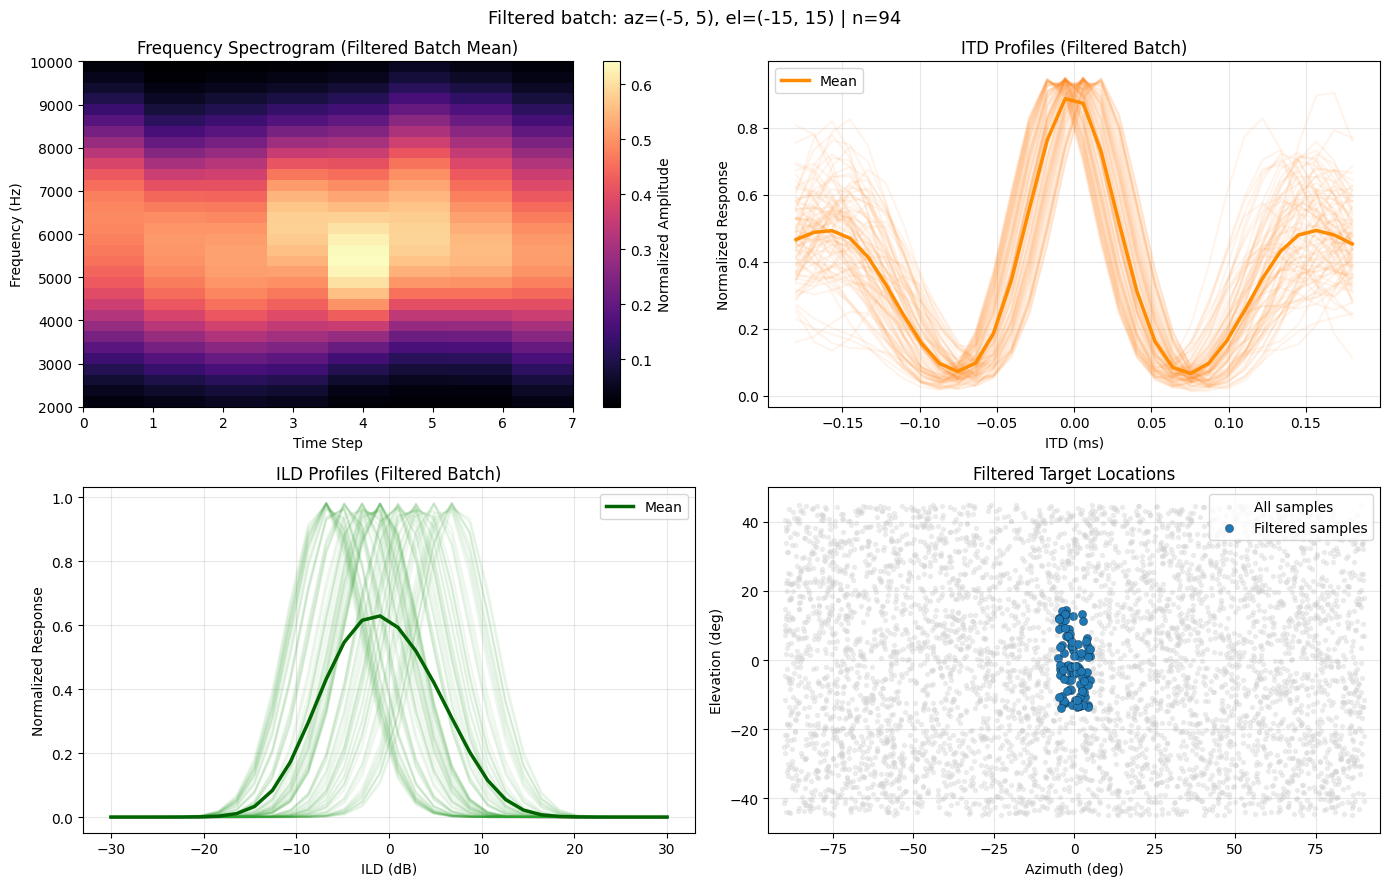

Matching samples: 466


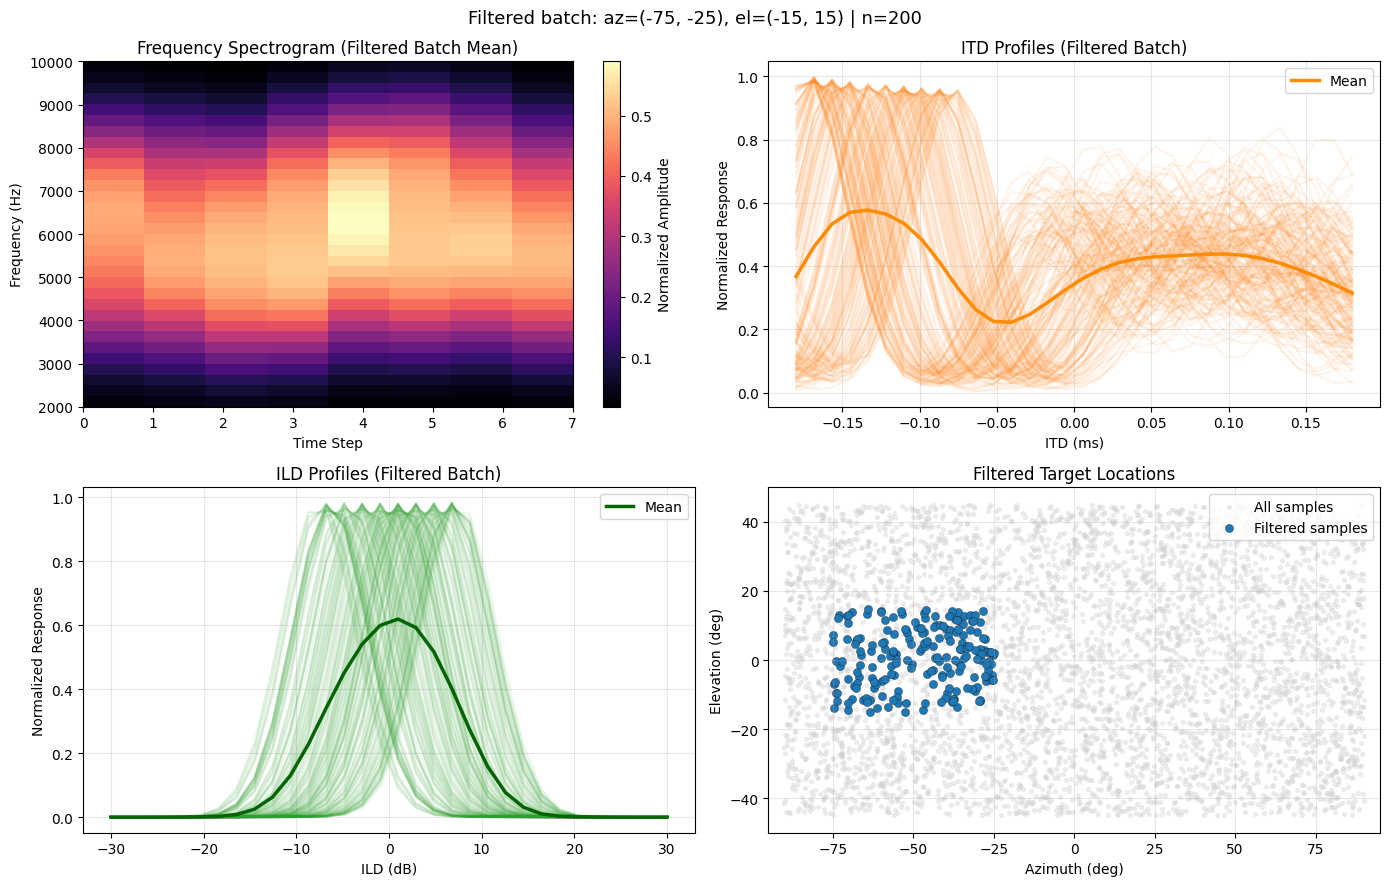

Matching samples: 475


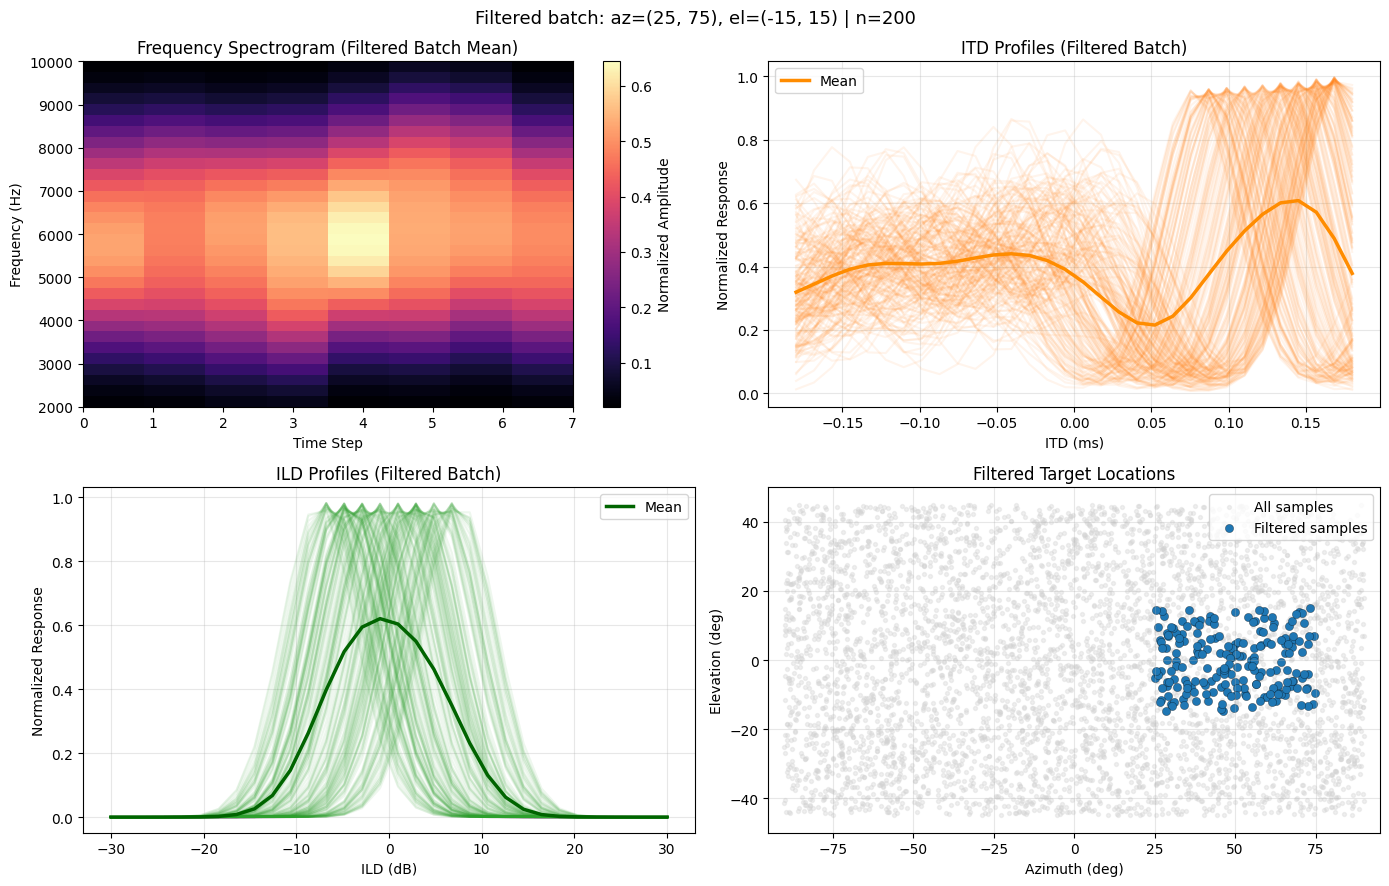

Matching samples: 205


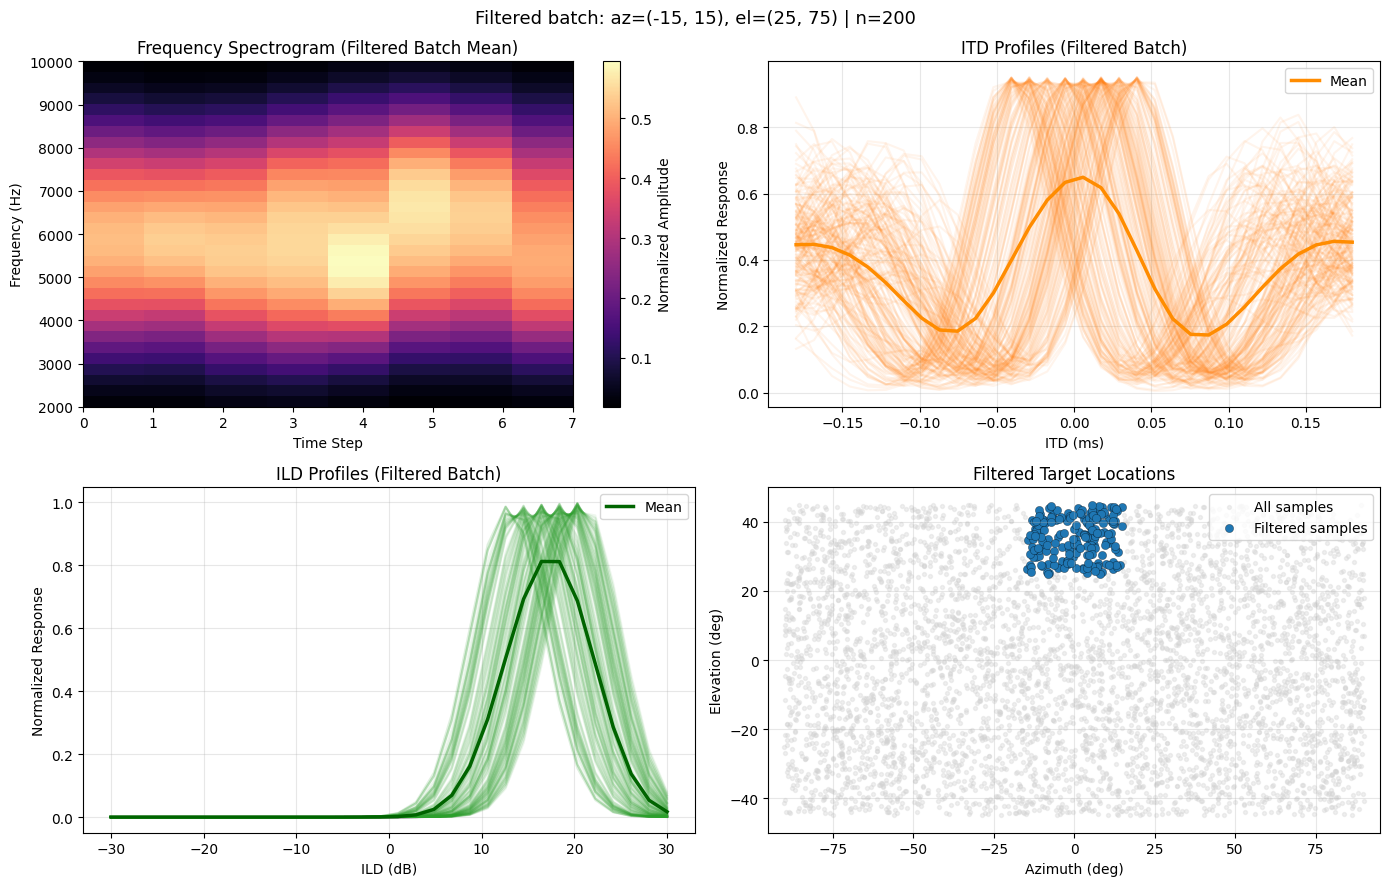

Matching samples: 310


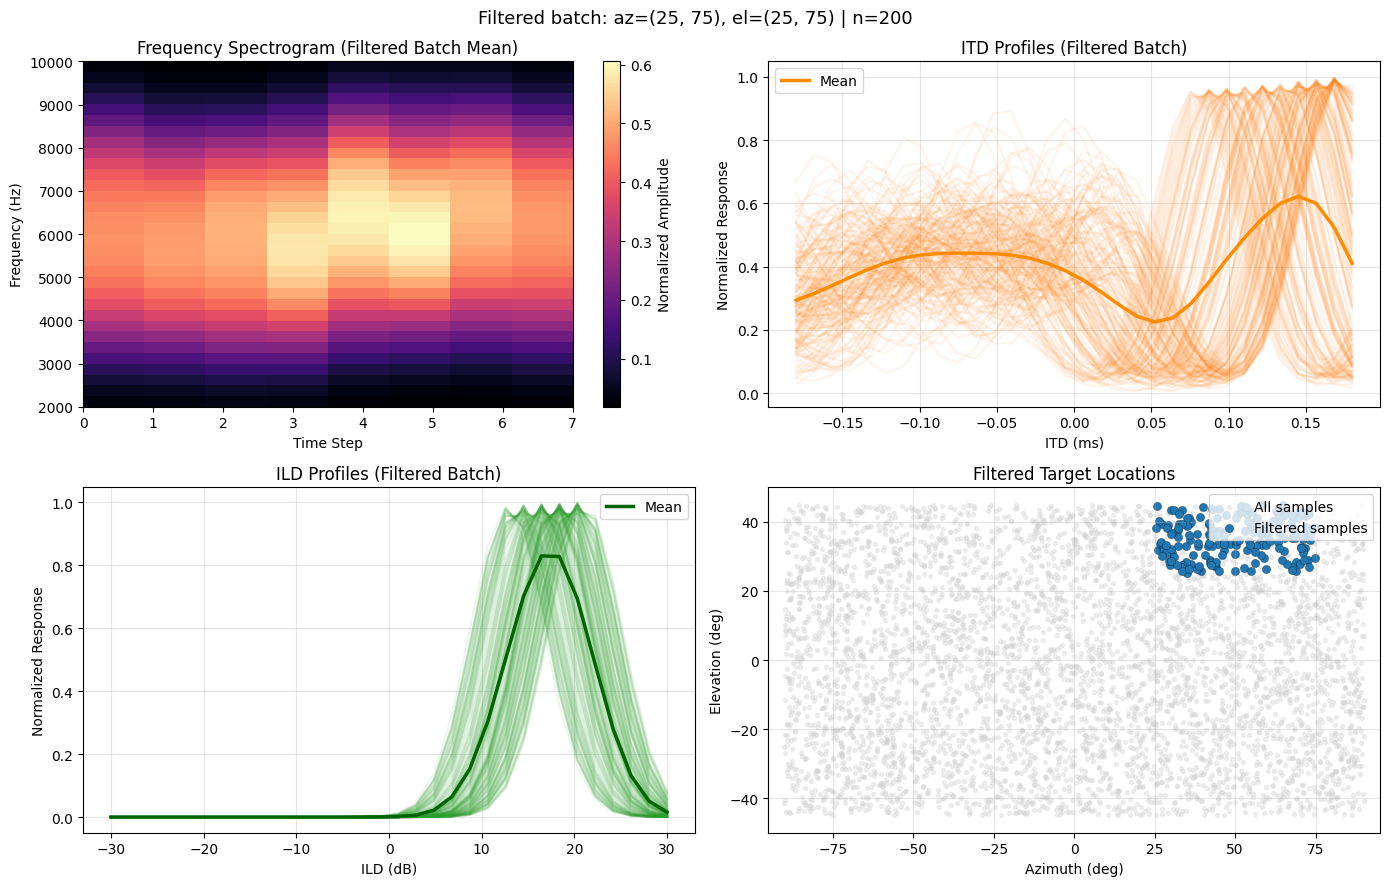

In [7]:
# Azmuth range (-5, 5)
selected_idx = plot_filtered_profiles(
    x_train,
    y_train,
    freq_axis,
    itd_axis,
    ild_axis,
    azimuth_range=(-5, 5),
    elevation_range=(-15, 15),
    max_samples=200,
    random_seed=42,
    show_individual=True,
)

# Azmuth range (-75, -25)
selected_idx = plot_filtered_profiles(
    x_train,
    y_train,
    freq_axis,
    itd_axis,
    ild_axis,
    azimuth_range=(-75, -25),
    elevation_range=(-15, 15),
    max_samples=200,
    random_seed=42,
    show_individual=True,
)

# Azmuth range (25, 75)
selected_idx = plot_filtered_profiles(
    x_train,
    y_train,
    freq_axis,
    itd_axis,
    ild_axis,
    azimuth_range=(25, 75),
    elevation_range=(-15, 15),
    max_samples=200,
    random_seed=42,
    show_individual=True,
)

# Elevation range (25, 75)
selected_idx = plot_filtered_profiles(
    x_train,
    y_train,
    freq_axis,
    itd_axis,
    ild_axis,
    azimuth_range=(-15, 15),
    elevation_range=(25, 75),
    max_samples=200,
    random_seed=42,
    show_individual=True,
)

# Elevation range (25, 75) & Azimuth range (25, 75)
selected_idx = plot_filtered_profiles(
    x_train,
    y_train,
    freq_axis,
    itd_axis,
    ild_axis,
    azimuth_range=(25, 75),
    elevation_range=(25, 75),
    max_samples=200,
    random_seed=42,
    show_individual=True,
)

In [10]:
# Normalize features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)

# Split into train/test
x_tr, x_te, y_tr, y_te = train_test_split(
    x_train_scaled, y_train, test_size=0.2, random_state=42
)

# Convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((x_tr, y_tr)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((x_te, y_te)).batch(32)

# Build regression model for [azimuth, elevation]
input_dim = x_train_scaled.shape[1]
output_dim = y_train.shape[1]

W0000 00:00:1785870391.423381  262836 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1785870391.504711  262836 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13702 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


# Create & Test ANN Model

In [22]:
import rANN_model
from rANN_model import rANN, PerTargetMAECallback, TargetMAE

In [23]:
ptcb = PerTargetMAECallback(x_te, y_te, x_train=x_tr, y_train=y_tr)

In [24]:
# Build a simple feedforward neural network with 3 hidden layers
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)), # Auditory features input
    tf.keras.layers.Dense(64, activation='relu'), # Toric Spines
    tf.keras.layers.Dense(64, activation='relu'), # Dendrites
    tf.keras.layers.Dense(64, activation='relu'), # Soma
    tf.keras.layers.Dense(output_dim, activation='linear') # Population Code?
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name='mae'),
        tf.keras.metrics.Accuracy(name='accuracy')]
)



Epoch 500/500 | train_loss=0.4012 | val_loss=3.7956 | mae_az=0.660deg | mae_el=0.244deg


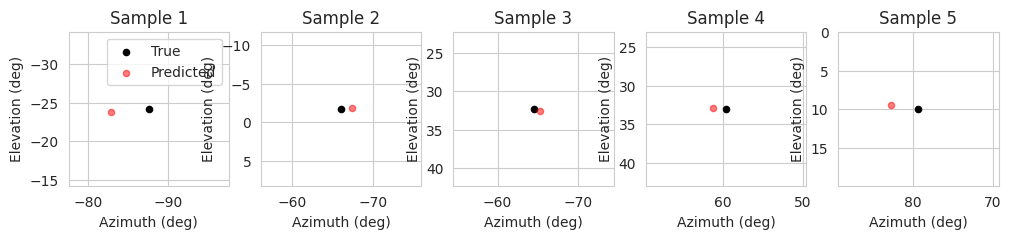

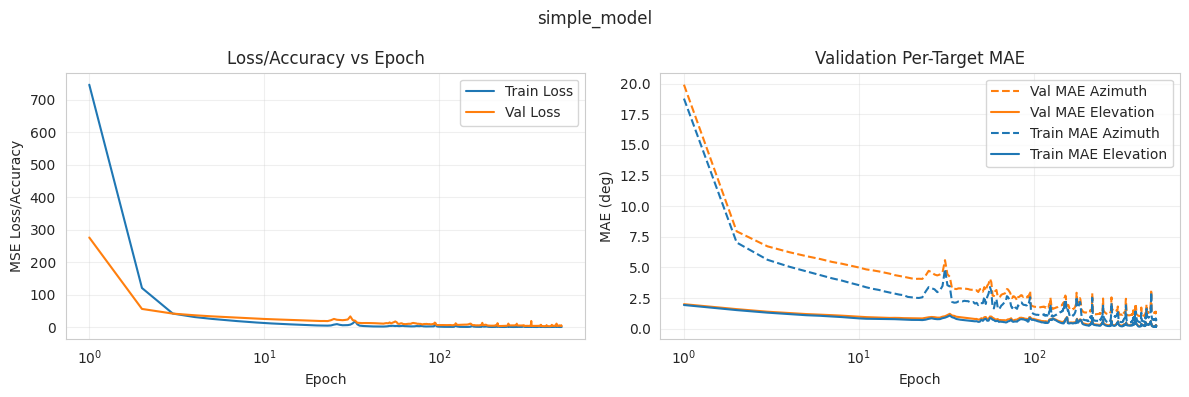

<Figure size 640x480 with 0 Axes>

In [25]:
# Train over an epoch range and track loss + per-target MAE
start_epoch = 1
end_epoch = 500  # inclusive
batch_size_eval = 256
n_samples = 5

train_loss = []
val_loss = []
mae_az = []
mae_el = []
val_mae_az = []
val_mae_el = []

for epoch in range(start_epoch, end_epoch + 1):
    # Train one epoch at a time so we can log metrics per epoch in a manual loop
    hist = model.fit(
        train_dataset, 
        validation_data=test_dataset, 
        epochs=1, 
        verbose=0,
        callbacks=[ptcb])

    train_loss.append(float(hist.history['loss'][-1]))
    val_loss.append(float(hist.history['val_loss'][-1]))

    # ── Per-target MAE ────────────────────────────────────────────────────────
    y_pred   = model.predict(x_te, verbose=0)
    #abs_err  = np.abs(y_pred - y_te)

    mae_az.append(float(hist.history['mae_az'][-1]))
    mae_el.append(float(hist.history['mae_el'][-1]))

    val_mae_az.append(float(hist.history['val_mae_az'][-1]))
    val_mae_el.append(float(hist.history['val_mae_el'][-1]))

    clear_output()

    print(
        f"Epoch {epoch:02d}/{end_epoch} | "
        f"train_loss={train_loss[-1]:.4f} | val_loss={val_loss[-1]:.4f} | "
        f"mae_az={mae_az[-1]:.3f}deg | mae_el={mae_el[-1]:.3f}deg"
    )

    fig, axes = plt.subplots(1, n_samples, figsize=(12, 2))
    
    for i in range(n_samples):
        # Plot real azmuth/elevation vs predicted for the first n_samples in the test set
        axes[i].scatter(y_te[:, 0][i], y_te[:, 1][i], color = 'black', s=20, label='True')
        axes[i].set_xlabel('Azimuth (deg)')
        axes[i].set_ylabel('Elevation (deg)')
        axes[i].set_xlim(y_te[:, 0][i] + 10, y_te[:, 0][i] - 10)
        axes[i].set_ylim(y_te[:, 1][i] + 10, y_te[:, 1][i] - 10)
        axes[i].set_title(f'Sample {i+1}')
        
        # Plot predicted azmuth/elevation for the first n_samples in the test set
        axes[i].scatter(y_pred[:, 0][i], y_pred[:, 1][i], color = 'red', s=20, alpha=0.5, label='Predicted')
        if i == 0:
            axes[i].legend()

    history = {'loss': train_loss, 'val_loss': val_loss, 'mae_az': mae_az, 'mae_el': mae_el, 'val_mae_az': val_mae_az, 'val_mae_el': val_mae_el}

    plot_training_history(history, run_name='simple_model', show=True, accuracy=False)
    
    plt.tight_layout()
    plt.show()

In [29]:
model = rANN(
        input_dim    = input_dim,
        output_dim   = output_dim,
        n_spines     = 64,
        n_dendrites_per_soma = 16,
        n_soma       = 64,
        spine_mask    = None,
        dendrite_mask = None,
        soma_mask     = None,
    )

model.compile(
    optimizer = 'adam', #tf.keras.optimizers.Adam(learning_rate=lr),
    loss      = tf.keras.losses.MeanSquaredError(),
    metrics   = [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.Accuracy(name="accuracy"),
        TargetMAE(0, name="mae_az"),
        TargetMAE(1, name="mae_el"),
    ],
)

I0000 00:00:1785872089.936110  263130 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1168874__.21


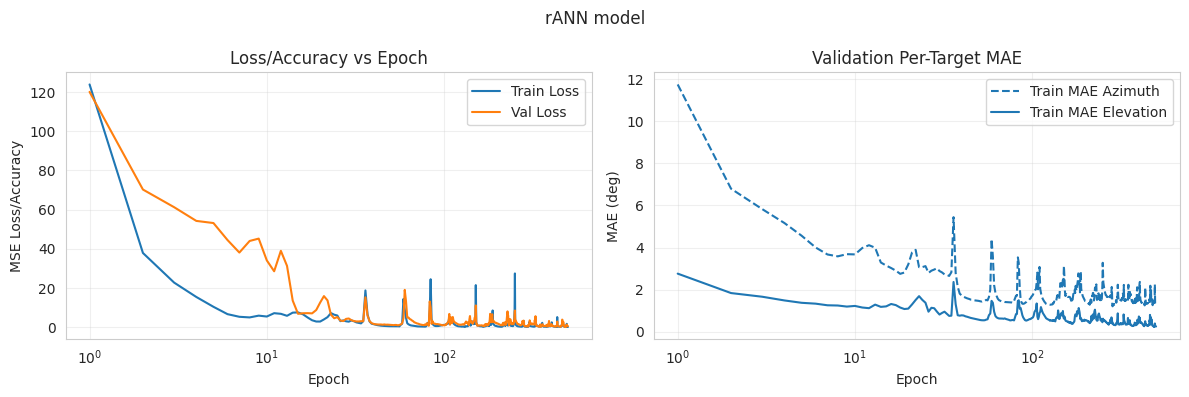

In [28]:
# Train and record loss + per-target MAE directly from Keras history
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=500,
    verbose=0,

)

history_dict = history.history
plot_training_history(history_dict, run_name='rANN model', show=False)


I0000 00:00:1785872165.402904  263134 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1748176__.21


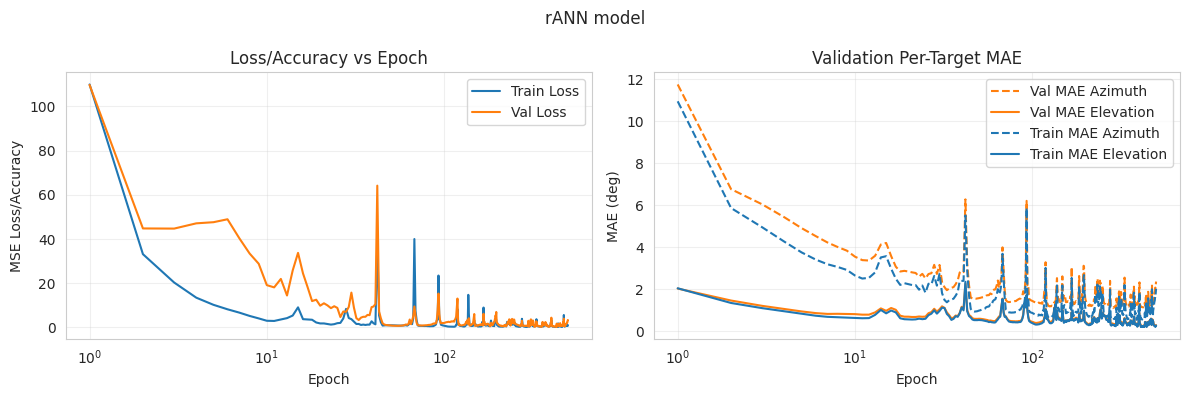

In [30]:
# Train and record loss + per-target MAE directly from Keras history
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=500,
    verbose=0,
    callbacks=[ptcb],
)

history_dict = history.history
plot_training_history(history_dict, run_name='rANN model', show=False)


In [ ]:
# Train over an epoch range and track loss + per-target MAE
start_epoch = 1
end_epoch = 10  # inclusive
batch_size_eval = 256
n_samples = 5

train_loss = []
val_loss = []
mae_az = []
mae_el = []
val_mae_az = []
val_mae_el = []

for epoch in range(start_epoch, end_epoch + 1):
    # Train one epoch at a time so we can log metrics per epoch in a manual loop
    hist = model.fit(
        train_dataset,
        validation_data=test_dataset,
        epochs=1,
        verbose=0,
        callbacks=[ptcb],
    )

    train_loss.append(float(hist.history['loss'][-1]))
    val_loss.append(float(hist.history['val_loss'][-1]))

    mae_az.append(float(hist.history['mae_az'][-1]))
    mae_el.append(float(hist.history['mae_el'][-1]))
    val_mae_az.append(float(hist.history['val_mae_az'][-1]))
    val_mae_el.append(float(hist.history['val_mae_el'][-1]))

    clear_output()

    print(
        f"Epoch {epoch:02d}/{end_epoch} | "
        f"train_loss={train_loss[-1]:.4f} | val_loss={val_loss[-1]:.4f} | "
        f"mae_az={mae_az[-1]:.3f}deg | mae_el={mae_el[-1]:.3f}deg"
    )

    fig, axes = plt.subplots(1, n_samples, figsize=(12, 2))
    
    for i in range(n_samples):
        axes[i].scatter(y_te[:, 0][i], y_te[:, 1][i], color='black', s=20, label='True')
        axes[i].set_xlabel('Azimuth (deg)')
        axes[i].set_ylabel('Elevation (deg)')
        axes[i].set_xlim(y_te[:, 0][i] + 10, y_te[:, 0][i] - 10)
        axes[i].set_ylim(y_te[:, 1][i] + 10, y_te[:, 1][i] - 10)
        axes[i].set_title(f'Sample {i+1}')
        axes[i].scatter(y_pred[:, 0][i], y_pred[:, 1][i], color='red', s=20, alpha=0.5, label='Predicted')
        if i == 0:
            axes[i].legend()

    history = {'loss': train_loss, 'val_loss': val_loss, 'mae_az': mae_az, 'mae_el': mae_el, 'val_mae_az': val_mae_az, 'val_mae_el': val_mae_el}

    plot_training_history(history, run_name='simple_model', show=True)
    plt.tight_layout()
    plt.show()


KeyError: 'val_mae_az'

# Testing new sweep config arcitecture 

In [26]:
import sweep_config
sweep_config = importlib.reload(sweep_config)
from sweep_config import build_sweep_configs, run_sweep_from_configs

In [9]:
from make_data import create_synthetic_dataset 

x_train, y_train, freq_axis, itd_axis, ild_axis = create_synthetic_dataset(n_samples=5000, itd_hwhh=0.03, ipd_aliases=2)

# Normalize features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)

# Split into train/test
x_tr, x_te, y_tr, y_te = train_test_split(
    x_train_scaled, y_train, test_size=0.2, random_state=42
)

training_data = (x_tr, y_tr)
testing_data = (x_te, y_te)

print(f'input_dim: {x_train_scaled.shape[1]}')
print(f'output_dim: {y_train.shape[1]}')

input_dim: 768
output_dim: 2


In [5]:
# Build all configs (generates masks on disk, returns JSON-safe list)
configs = build_sweep_configs(
    output_root          = "/home/mrsarti/rANN/sweep_results/all_runs",
    spine_sizes          = [768],
    dendrite_per_soma_sizes = [4],
    soma_sizes           = [128],
    itd_spine_frac_names = ["equal_split", "itd_heavy", "ild_heavy"],
    overlap_names        = ["strict", "25pct", "50pct"],
    dendrite_rules       = ["topographic", "interleaved", "random"],
    channel_dend_split_names = ["split", "merged"],
    input_dim            = 32*3*8,
    output_dim           = 2,
)

Building 55 configs (1 size × 54 topology × 1 activation + 1 (+ baseline))…
  Reused mask → /home/mrsarti/rANN/sweep_results/all_runs/constrained_s768_d4ps_so128_ifequal_split_ovstrict_drtopographic_cdsplit/mask.npz
  Reused mask → /home/mrsarti/rANN/sweep_results/all_runs/alltoall_s768_d4ps_so128/mask.npz
  Reused mask → /home/mrsarti/rANN/sweep_results/all_runs/constrained_s768_d4ps_so128_ifequal_split_ovstrict_drtopographic_cdmerged/mask.npz
  Reused mask → /home/mrsarti/rANN/sweep_results/all_runs/constrained_s768_d4ps_so128_ifequal_split_ovstrict_drinterleaved_cdsplit/mask.npz
  Reused mask → /home/mrsarti/rANN/sweep_results/all_runs/constrained_s768_d4ps_so128_ifequal_split_ovstrict_drinterleaved_cdmerged/mask.npz
  Reused mask → /home/mrsarti/rANN/sweep_results/all_runs/constrained_s768_d4ps_so128_ifequal_split_ovstrict_drrandom_cdsplit/mask.npz
  Reused mask → /home/mrsarti/rANN/sweep_results/all_runs/constrained_s768_d4ps_so128_ifequal_split_ovstrict_drrandom_cdmerged/mask.npz

In [30]:
# Build all configs (generates masks on disk, returns JSON-safe list)
configs = build_sweep_configs(
    output_root          = "/home/mrsarti/rANN/sweep_results/test",
    spine_sizes          = [1536],
    dendrite_per_soma_sizes = [4],
    soma_sizes           = [192],
    itd_spine_frac_names = ["equal_split"],
    overlap_names        = ["strict"],
    dendrite_rules       = ["topographic"],
    channel_dend_split_names = ["split"],
    input_dim            = 32*3*8,
    output_dim           = 2,
)

Building 2 configs (1 size × 1 topology × 1 activation + 1 (+ baseline))…
  Saved mask  → /home/mrsarti/rANN/sweep_results/test/constrained_s1536_d4ps_so192_ifequal_split_ovstrict_drtopographic_cdsplit/mask.npz
  Saved mask  → /home/mrsarti/rANN/sweep_results/test/alltoall_s1536_d4ps_so192/mask.npz
Done — 2 configs ready.



[1/2]  constrained_s1536_d4ps_so192_ifequal_split_ovstrict_drtopographic_cdsplit
Saved mask figure → /home/mrsarti/rANN/sweep_results/test/constrained_s1536_d4ps_so192_ifequal_split_ovstrict_drtopographic_cdsplit/masks_constrained_s1536_dps4_so192_ifequal_split_ovstrict_drtopographic_cdsplit.png
Saved architecture figure -> /home/mrsarti/rANN/sweep_results/test/constrained_s1536_d4ps_so192_ifequal_split_ovstrict_drtopographic_cdsplit/arch_constrained_s1536_dps4_so192_ifequal_split_ovstrict_drtopographic_cdsplit.png


I0000 00:00:1786043908.841077 1493190 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7351858__.21
I0000 00:00:1786043909.082566 2224871 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_matmul_10', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1786043909.734171 2224882 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1786043913.391832 2225192 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_matmul_8', 12 bytes spill stores, 8 bytes spill loads

I0000 00:00:1786043913.417499 2225196 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_matmul_8', 12 bytes spill stores, 8 bytes spill loads



  constrained_s1536_d4ps_so192_ifequal_split_ovstrict_drtopographic_cdsplit  val_loss=1159.318  mae_az=37.29°  mae_el=1.83°  epoch_90=  87  time=157.3s
  Saved training plot -> /home/mrsarti/rANN/sweep_results/test/constrained_s1536_d4ps_so192_ifequal_split_ovstrict_drtopographic_cdsplit/training_history.png


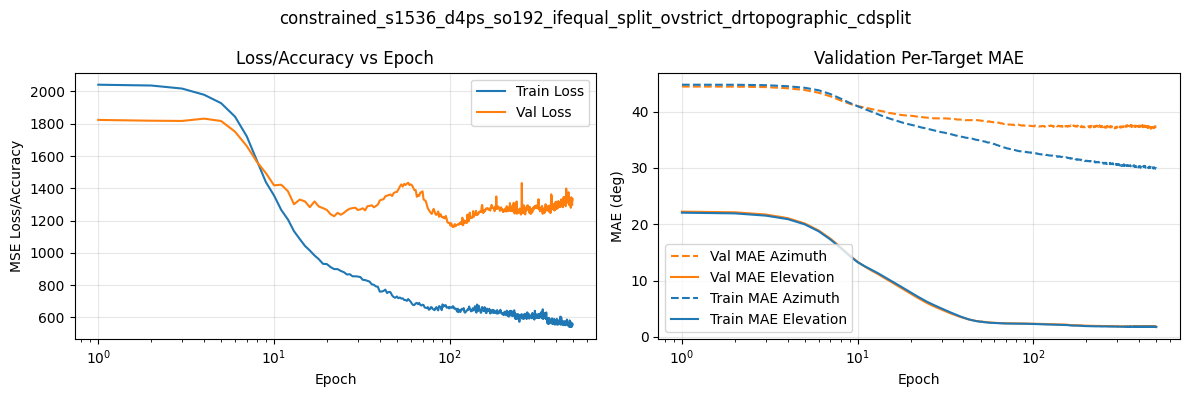

  Saved training plot -> /home/mrsarti/rANN/sweep_results/test/constrained_s1536_d4ps_so192_ifequal_split_ovstrict_drtopographic_cdsplit/final_weights.png


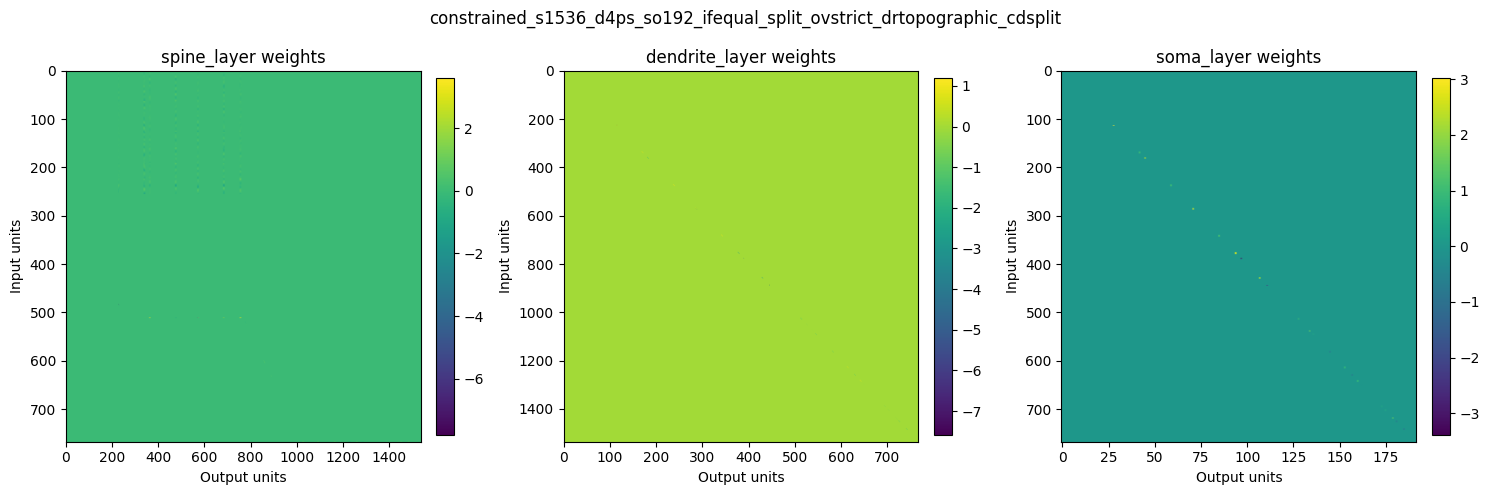


[2/2]  alltoall_s1536_d4ps_so192
Saved mask figure → /home/mrsarti/rANN/sweep_results/test/alltoall_s1536_d4ps_so192/masks_alltoall_s1536_dps4_so192_alltoall.png
Saved architecture figure -> /home/mrsarti/rANN/sweep_results/test/alltoall_s1536_d4ps_so192/arch_alltoall_s1536_dps4_so192_alltoall.png


I0000 00:00:1786044068.068424 1493201 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8541672__.21


In [ ]:
df = run_sweep_from_configs(
        configs= configs,
        training_data = (x_tr, y_tr),    
        testing_data = (x_te, y_te),
        plot_history = True,
        plot_weights = True,
        output_root = "/home/mrsarti/rANN/sweep_results/test"
    )

Keys: ['input_spine', 'spine_dendrite', 'dendrite_soma']
input_spine: shape=(768, 768), dtype=float32, min=0.0, max=1.0
spine_dendrite: shape=(768, 512), dtype=float32, min=0.0, max=1.0
dendrite_soma: shape=(512, 128), dtype=float32, min=0.0, max=1.0


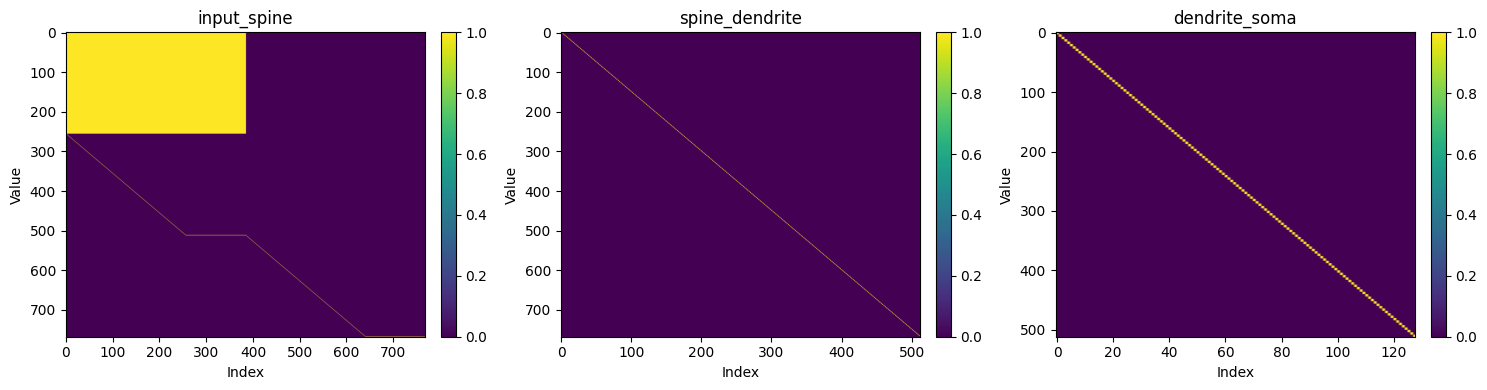

In [ ]:
# Function to plot masks from a .npz file

mask_path = "/home/mrsarti/rANN/sweep_results/test/constrained_s768_d4ps_so128_ifequal_split_ovstrict_drtopographic_cdsplit/mask.npz"

def plot_masks_from_path(mask_path):
    """Load and plot masks from a .npz file."""
    mask_data = np.load(mask_path)
    print("Keys:", mask_data.files)

    fig, axes = plt.subplots(1, len(mask_data.files), figsize=(5 * len(mask_data.files), 4))
    if len(mask_data.files) == 1:
        axes = [axes]

    for ax, key in zip(axes, mask_data.files):
        arr = mask_data[key]
        print(f"{key}: shape={arr.shape}, dtype={arr.dtype}, min={arr.min()}, max={arr.max()}")
        if arr.ndim == 1:
            ax.plot(arr)
        else:
            im = ax.imshow(arr, aspect="auto", cmap="viridis")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(key)
        ax.set_xlabel("Index")
        ax.set_ylabel("Value")

    plt.tight_layout()
    plt.show()

plot_masks_from_path(mask_path)

In [83]:
df.head(5)

,run_name,tag,run_dir,mode,constrained,mask_npz_path,mask_meta_path,input_dim,output_dim,n_spines,...,l2_reg,patience,n_epochs_trained,final_val_loss,final_mae_az,final_mae_el,wall_time_s,final_train_loss,epoch_90pct,convergence_efficiency
0,constrained_s768_d4ps_so128_ifequal_split_ovst...,constrained_s768_d4ps_so128_ifequal_split_ovst...,/home/mrsarti/rANN/sweep_results/all_runs/cons...,constrained,True,/home/mrsarti/rANN/sweep_results/all_runs/cons...,/home/mrsarti/rANN/sweep_results/all_runs/cons...,768,2,768,...,0.0001,None,0,242.728241,33.837570,0.147827,140.03,513.857727,66,0.271909
1,alltoall_s768_d4ps_so128,alltoall_s768_d4ps_so128,/home/mrsarti/rANN/sweep_results/all_runs/allt...,alltoall,False,/home/mrsarti/rANN/sweep_results/all_runs/allt...,/home/mrsarti/rANN/sweep_results/all_runs/allt...,768,2,768,...,0.0001,None,0,0.741951,1.882435,0.494965,141.23,2.283388,13,17.521384
2,constrained_s768_d4ps_so128_ifequal_split_ovst...,constrained_s768_d4ps_so128_ifequal_split_ovst...,/home/mrsarti/rANN/sweep_results/all_runs/cons...,constrained,True,/home/mrsarti/rANN/sweep_results/all_runs/cons...,/home/mrsarti/rANN/sweep_results/all_runs/cons...,768,2,768,...,0.0001,None,0,162.232941,32.180870,0.163819,137.58,600.362000,30,0.184919
3,constrained_s768_d4ps_so128_ifequal_split_ovst...,constrained_s768_d4ps_so128_ifequal_split_ovst...,/home/mrsarti/rANN/sweep_results/all_runs/cons...,constrained,True,/home/mrsarti/rANN/sweep_results/all_runs/cons...,/home/mrsarti/rANN/sweep_results/all_runs/cons...,768,2,768,...,0.0001,None,0,321.896332,31.401026,0.141941,138.93,380.419952,16,0.049705
4,constrained_s768_d4ps_so128_ifequal_split_ovst...,constrained_s768_d4ps_so128_ifequal_split_ovst...,/home/mrsarti/rANN/sweep_results/all_runs/cons...,constrained,True,/home/mrsarti/rANN/sweep_results/all_runs/cons...,/home/mrsarti/rANN/sweep_results/all_runs/cons...,768,2,768,...,0.0001,None,0,250.672607,35.702015,0.265966,140.61,200.276428,15,0.059839


In [84]:
print("\n── Top 10 constrained runs by val_loss ──")
cols = ["run_name", "n_spines", "n_dendrites_per_soma", "total_dendrites", "n_soma",
        "final_val_loss", "final_mae_az", "final_mae_el",
        "epoch_90pct", #"weight_reduction", 
        "wall_time_s"]
print(df[df["constrained"] == True][cols].head(10).to_string(index=False))


── Top 10 constrained runs by val_loss ──
                                                                 run_name  n_spines  n_dendrites_per_soma  total_dendrites  n_soma  final_val_loss  final_mae_az  final_mae_el  epoch_90pct  wall_time_s
 constrained_s768_d4ps_so128_ifequal_split_ovstrict_drtopographic_cdsplit       768                     4              512     128      242.728241     33.837570      0.147827           66       140.03
constrained_s768_d4ps_so128_ifequal_split_ovstrict_drtopographic_cdmerged       768                     4              512     128      162.232941     32.180870      0.163819           30       137.58
 constrained_s768_d4ps_so128_ifequal_split_ovstrict_drinterleaved_cdsplit       768                     4              512     128      321.896332     31.401026      0.141941           16       138.93
constrained_s768_d4ps_so128_ifequal_split_ovstrict_drinterleaved_cdmerged       768                     4              512     128      250.672607     35

In [2]:
# Epoch at which 90% of final performance is reached (lower is better)
from analyze_data import plot_epoch_90pct_ranking, plot_epoch_90pct_comparison, plot_by_metrics

#plot_epoch_90pct_ranking(df, metric_col='epoch_90pct')

plot_by_metrics(df, metric_x_col = 'epoch_90pct', metric_y_col = 'final_val_loss')


NameError: name 'df' is not defined

# Sweep Test

Generating 5000 synthetic samples...
  train: (4000, 768)  test: (1000, 768)

Building biological masks...
  1 topology configs  ·  1 unique sizes (baselines) = 2 total runs


Config: spines=64, dendrites/soma=4, somas=16, topology={'itd_frac_name': 'equal_split', 'overlap_name': '50pct', 'dendrite_rule': 'random', 'channel_dend_split_name': 'split'}
Saved mask figure → /home/mrsarti/rANN/sweep_results/runs/constrained_s64_d4ps_so16_ifequal_split_ov50pct_drrandom_cdsplit/masks_constrained_s64_dps4_so16_ifequal_split_ov50pct_drrandom_cdsplit.png
Saved architecture figure -> /home/mrsarti/rANN/sweep_results/runs/constrained_s64_d4ps_so16_ifequal_split_ov50pct_drrandom_cdsplit/arch_constrained_s64_dps4_so16_ifequal_split_ov50pct_drrandom_cdsplit.png
  [VERIFY FAILED] constrained_s64_d4ps_so16_ifequal_split_ov50pct_drrandom_cdsplit

  Mask verification: FAILED

── Biological rules ──
  PASS  All 32 ITD spines receive full frequency broadcast
  PASS  All 32 ILD spines receive no frequency i

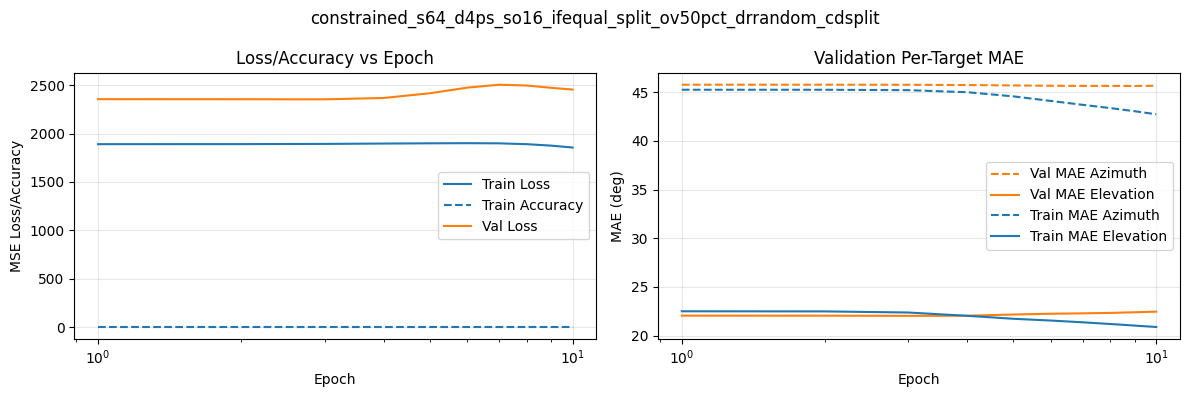

  Saved training plot -> /home/mrsarti/rANN/sweep_results/runs/constrained_s64_d4ps_so16_ifequal_split_ov50pct_drrandom_cdsplit/final_weights.png


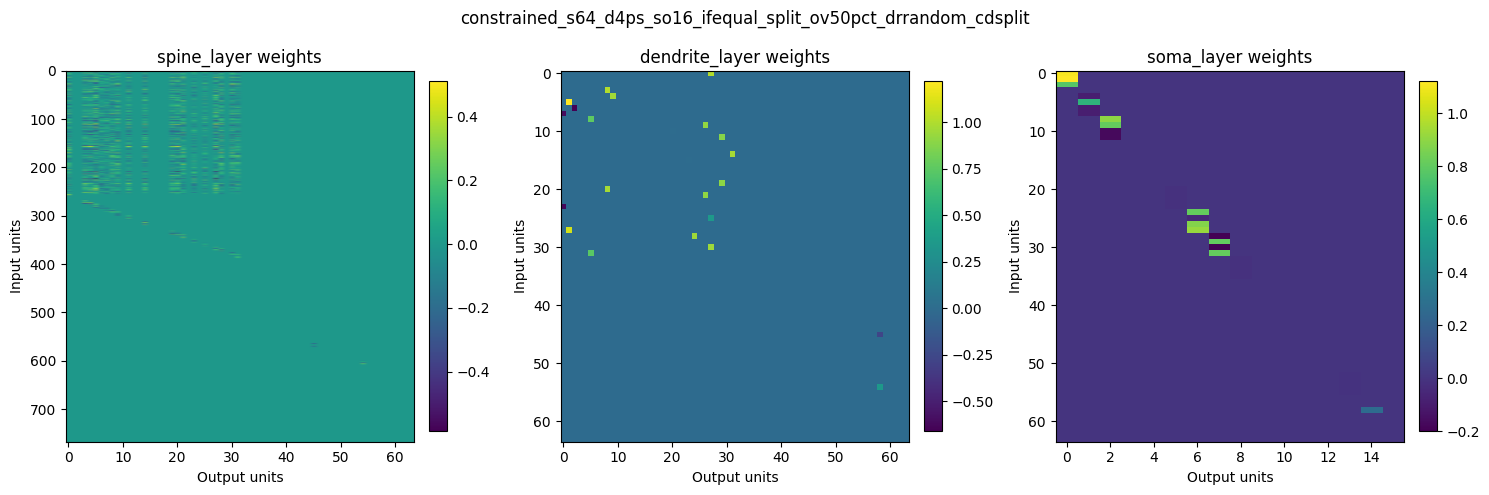

  constrained_s64_d4ps_so16_ifequal_split_ov50pct_drrandom_cdsplit  val_loss=2353.850  mae_az=45.65°  mae_el=22.47°  epoch_90=   3  time=3.3s
Saved mask figure → /home/mrsarti/rANN/sweep_results/runs/alltoall_s64_d4ps_so16/masks_alltoall_s64_dps4_so16.png
Saved architecture figure -> /home/mrsarti/rANN/sweep_results/runs/alltoall_s64_d4ps_so16/arch_alltoall_s64_dps4_so16.png
[2/2] alltoall_s64_d4ps_so16
(4000, 768) (4000, 2) (1000, 768) (1000, 2)
  alltoall_s64_d4ps_so16                    val_loss=2543.385  mae_az=52.16°  mae_el=26.69°  time=2.8s
  Saved training plot -> /home/mrsarti/rANN/sweep_results/runs/alltoall_s64_d4ps_so16/training_history.png


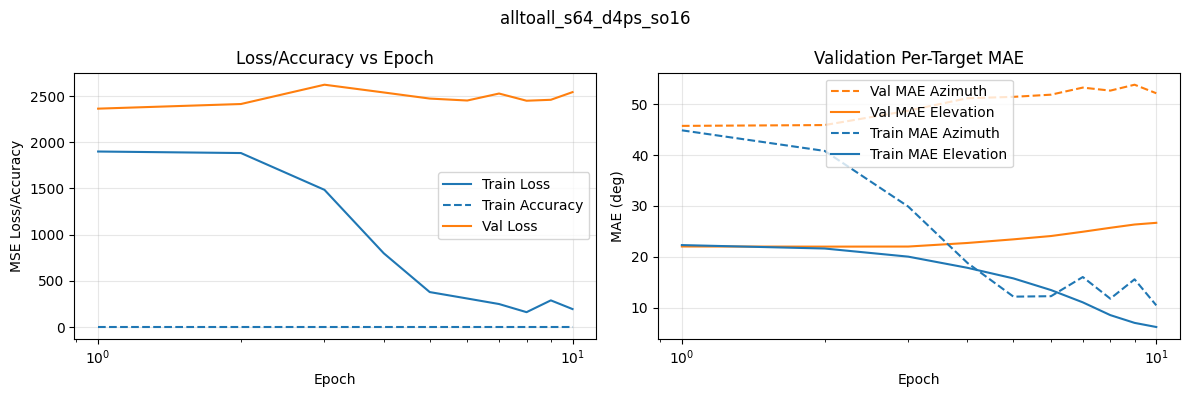

  Saved training plot -> /home/mrsarti/rANN/sweep_results/runs/alltoall_s64_d4ps_so16/final_weights.png


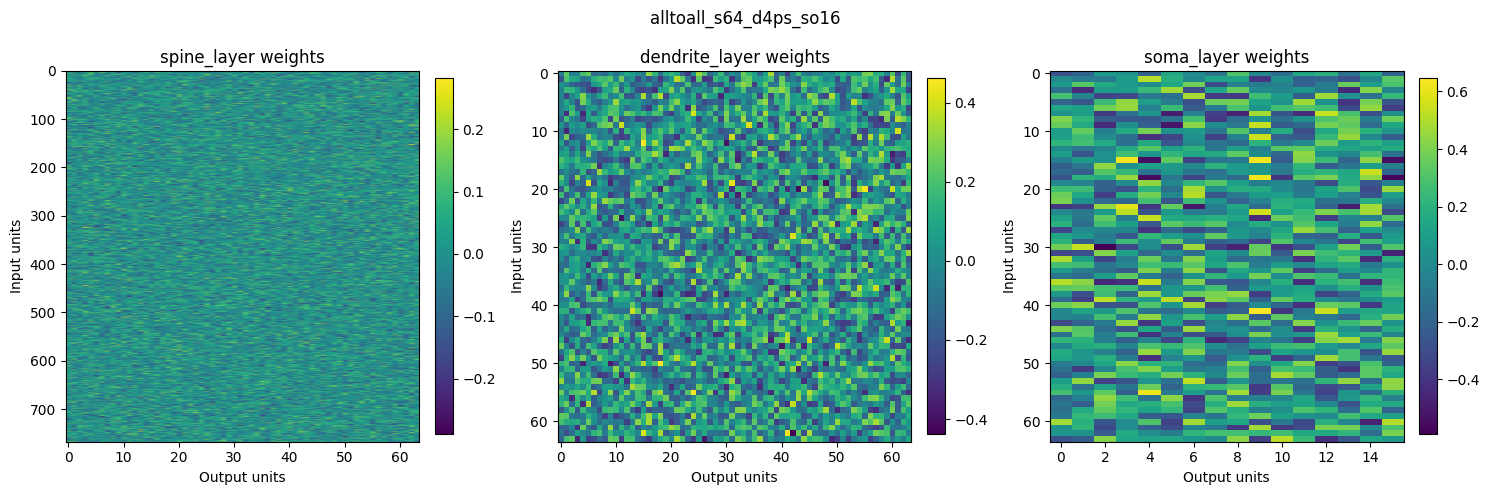

  alltoall_s64_d4ps_so16                    val_loss=2364.513  mae_az=52.16°  mae_el=26.69°  epoch_90=   1  time=2.8s

Summary saved → /home/mrsarti/rANN/sweep_results/sweep_summary.csv
DataFrame shape: (2, 24)

── Top 10 constrained runs by val_loss ──
                                                        run_name  n_spines  n_dendrites_per_soma  total_dendrites  n_soma  final_val_loss  final_mae_az  final_mae_el  epoch_90pct  weight_reduction  wall_time_s
constrained_s64_d4ps_so16_ifequal_split_ov50pct_drrandom_cdsplit        64                     4               64      16     2353.850098      45.64753     22.468578            3              83.7         3.29


In [8]:
from sweep_runner import run_sweep
sweep_runner = importlib.reload(sweep_runner)


df = run_sweep(
    spine_sizes    = [64], #[2**i for i in range(7,10)],       # one spine size instead of three
    dendrite_per_soma_sizes = [4], #[2**i for i in range(1,4)],         # one dendrite count instead of five
    soma_sizes     = [16], #[2**i for i in range(7,10)],       # one soma size instead of three
    epochs         = 10,          # 20 instead of 500
    n_samples      = 5000,         # 500 instead of 5000
    batch_size     = 32,
    lr             = 5e-4,
    l2_reg         = 5e-4,
    include_baseline = True,      # still trains both variants so comparison logic runs

    itd_spine_frac_names= ['equal_split'],
    overlap_names = ['50pct'],
    dendrite_rules= ['random'],
    channel_dend_split_names= ['split'],

    # itd_spine_frac_names= ['equal_split', 'itd_heavy','ild_heavy'],
    # overlap_names= ['strict', '25pct','50pct'],
    # dendrite_rules= ['topographic', 'interleaved','random'],
    # channel_dend_split_names= ['split', 'merged'],

    plot_history= True,
    plot_weights=True,
    plot_mask=True,
    plot_architecture=True,
    patience=None
)

# df = run_sweep(epochs=500, n_samples=5000)
print("\n── Top 10 constrained runs by val_loss ──")
cols = ["run_name", "n_spines", "n_dendrites_per_soma", "total_dendrites", "n_soma",
        "final_val_loss", "final_mae_az", "final_mae_el",
        "epoch_90pct", "weight_reduction", "wall_time_s"]
print(df[df["constrained"] == True][cols].head(10).to_string(index=False))

In [ ]:
from sweep_runner import run_sweep

df = run_sweep(
    spine_sizes    = [512], #[2**i for i in range(7,10)],       # one spine size instead of three
    dendrite_per_soma_sizes = [4], #[2**i for i in range(1,4)],         # one dendrite count instead of five
    soma_sizes     = [8], #[2**i for i in range(7,10)],       # one soma size instead of three
    epochs         = 500,          # 20 instead of 500
    n_samples      = 1000,         # 500 instead of 5000
    batch_size     = 64,
    lr             = 5e-4,
    l2_reg         = 5e-4,
    include_baseline = True,      # still trains both variants so comparison logic runs
    patience       = None,

    itd_spine_frac_names= ['equal_split', 'itd_heavy','ild_heavy'],
    overlap_names= ['strict', '25pct','50pct'],
    dendrite_rules= ['topographic', 'interleaved','random'],
    channel_dend_split_names= ['split', 'merged'],

    plot_history= True,

)

# df = run_sweep(epochs=500, n_samples=5000)
print("\n── Top 10 constrained runs by val_loss ──")
cols = ["run_name", "n_spines", "n_dendrites_per_soma", "total_dendrites", "n_soma",
        "final_val_loss", "final_mae_az", "final_mae_el",
        "epoch_90pct", "weight_reduction", "wall_time_s"]
print(df[df["constrained"] == True][cols].head(10).to_string(index=False))

Took 76m 23.1s for run 

In [9]:
import pandas as pd
df = pd.read_csv('/home/mrsarti/rANN/sweep_results/sweep_summary.csv')
df

,run_name,run_dir,constrained,n_spines,n_dendrites_per_soma,total_dendrites,n_soma,trainable_params,active_weights,all2all_weights,...,final_train_loss,final_val_loss,final_mae_az,final_mae_el,epoch_90pct,wall_time_s,itd_frac_name,overlap_name,dendrite_rule,channel_dend_split_name
0,constrained_s64_d4ps_so16_ifequal_split_ov50pc...,/home/mrsarti/rANN/sweep_results/runs/constrai...,True,64,4,64,16,54450,8832.0,54272.0,...,1855.658081,2353.850098,45.647530,22.468578,3,3.29,equal_split,50pct,random,split
1,alltoall_s64_d4ps_so16,/home/mrsarti/rANN/sweep_results/runs/alltoall...,False,64,4,64,16,54450,NaN,NaN,...,194.274490,2364.512939,52.157284,26.686464,1,2.75,NaN,NaN,NaN,NaN


# Analyze After Training Swath

In [ ]:
import analyze_data
analyze_data = importlib.reload(analyze_data)
from analyze_data import load_sweep_summary, plot_val_loss_ranking, plot_val_loss_comparison, plot_mae_ranking, plot_mae_comparison, plot_epoch_90pct_ranking, plot_epoch_90pct_comparison



In [ ]:
# Accuracy comparison: validation loss ranking and MAE per-target ranking
summary_csv = '/home/mrsarti/rANN/sweep_results/sweep_summary.csv'
summary_df = load_sweep_summary(summary_csv)

plot_

# Epoch at which 90% of final performance is reached (lower is better)
plot_epoch_90pct_ranking(df)

# Epoch at which 90% of final performance is reached: constrained vs alltoall comparison
plot_epoch_90pct_comparison(df)

# Validation loss ranking (lower is better)
plot_val_loss_ranking(summary_df)

# Validation loss: constrained vs alltoall comparison
plot_val_loss_comparison(summary_df)

# Per-target MAE ranking — azimuth
plot_mae_ranking(summary_df, target='az')

# Per-target MAE ranking — elevation
plot_mae_ranking(summary_df, target='el')

# Per-target MAE ranking — combined (mean of az and el)
plot_mae_ranking(summary_df, target='combined')

# Per-target MAE comparison: constrained vs alltoall (combined)
plot_mae_comparison(summary_df, target='combined')


KeyError: "'Please specify a valid metric column. Available columns: ['run_name', 'run_dir', 'constrained', 'n_spines', 'n_dendrites_per_soma', 'total_dendrites', 'n_soma', 'trainable_params', 'active_weights', 'all2all_weights', 'weight_reduction', 'density_overall', 'topology_png', 'arch_png', 'final_train_loss', 'final_val_loss', 'final_mae_az', 'final_mae_el', 'epoch_90pct', 'wall_time_s', 'itd_frac_name', 'overlap_name', 'dendrite_rule', 'channel_dend_split_name']"

In [11]:

# Accuracy comparison: validation loss ranking and MAE per-target ranking
from analyze_data import load_sweep_summary, plot_val_loss_ranking, plot_val_loss_comparison, plot_mae_ranking, plot_mae_comparison

summary_csv = '/home/mrsarti/rANN/sweep_results/test_sweep_summary.csv'
summary_df = load_sweep_summary(summary_csv)

# Validation loss ranking (lower is better)
plot_val_loss_ranking(summary_df)

# Validation loss: constrained vs alltoall comparison
plot_val_loss_comparison(summary_df)

# Per-target MAE ranking — azimuth
plot_mae_ranking(summary_df, target='az')

# Per-target MAE ranking — elevation
plot_mae_ranking(summary_df, target='el')

# Per-target MAE ranking — combined (mean of az and el)
plot_mae_ranking(summary_df, target='combined')

# Per-target MAE comparison: constrained vs alltoall (combined)
plot_mae_comparison(summary_df, target='combined')


FileNotFoundError: Summary CSV not found: /home/mrsarti/rANN/sweep_results/test_sweep_summary.csv

# Check For Mask Application

In [70]:
import plot_swath_masks
plot_swath_masks = importlib.reload(plot_swath_masks)
from plot_swath_masks import plot_swath_masks

  plot_swath_masks: skipped 53 duplicate all-to-all config(s) (same size, always identical mask).


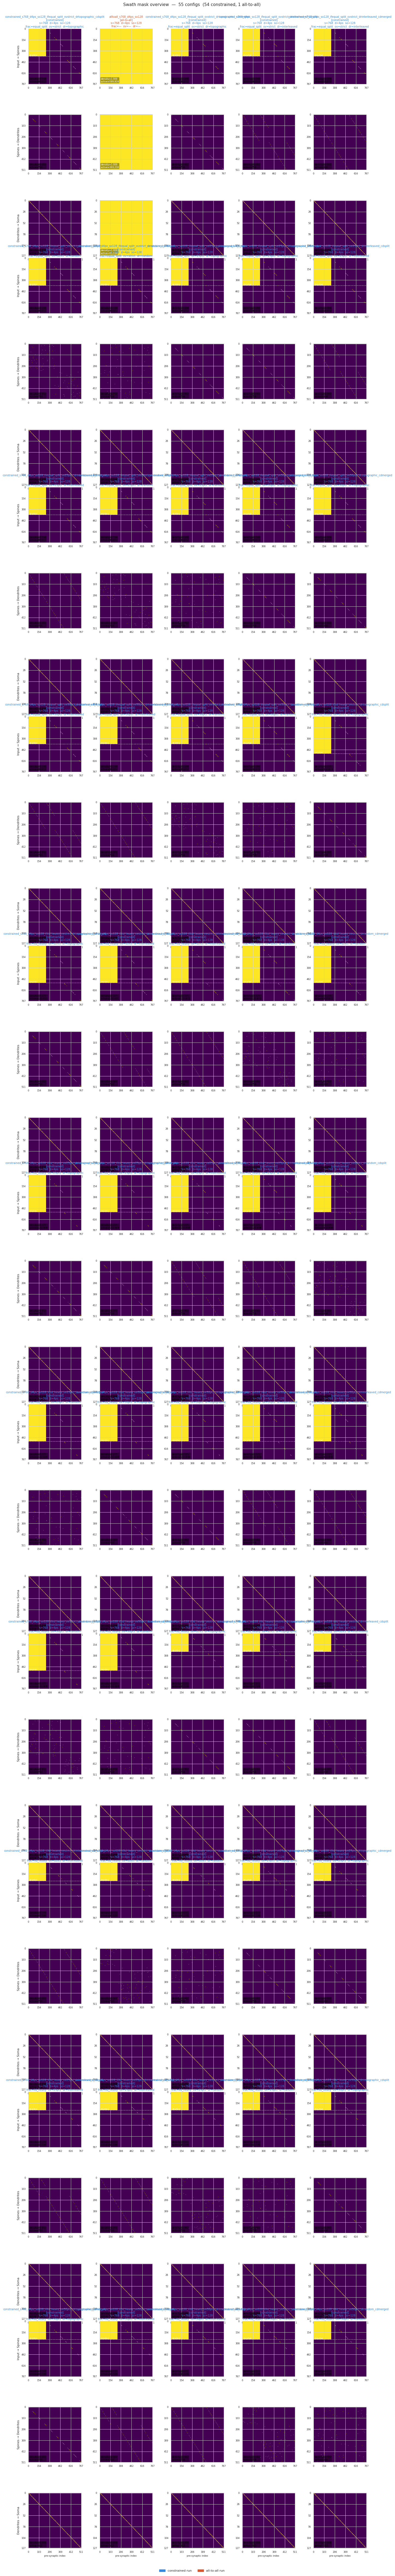

In [72]:
fig = plot_swath_masks(configs, max_cols=5)

In [12]:
import importlib
import os
import json

import sweep_runner
sweep_runner = importlib.reload(sweep_runner)
from sweep_runner import plot_train_step_diagnostics

In [13]:
summary_csv = '/home/mrsarti/rANN/sweep_results/sweep_summary.csv'
summary_df = pd.read_csv(summary_csv) if os.path.exists(summary_csv) else pd.DataFrame()

model = None
run_name = 'train_step_demo'
run_dir = None
x_batch = None
y_batch = None

In [14]:
if model is None:
    rng = np.random.default_rng(42)
    x_batch = rng.standard_normal((8, 6)).astype(np.float32)
    y_batch = rng.standard_normal((8, 2)).astype(np.float32)
    spine_mask = np.array([
        [1, 0, 1],
        [0, 1, 1],
        [1, 1, 0],
        [1, 0, 0],
        [0, 1, 0],
        [1, 1, 1],
    ], dtype=np.float32)
    dendrite_mask = np.array([
        [1, 1, 0, 1],
        [1, 0, 1, 1],
        [0, 1, 1, 1],
    ], dtype=np.float32)
    soma_mask = np.array([
        [1, 1, 0, 1],
        [1, 0, 1, 1],
        [0, 1, 1, 1],
        [1, 1, 1, 0],
    ], dtype=np.float32)
    model = sweep_runner.rANN(
        input_dim=6,
        output_dim=2,
        n_spines=3,
        n_dendrites_per_soma=1,
        n_soma=4,
        spine_mask=spine_mask,
        dendrite_mask=dendrite_mask,
        soma_mask=soma_mask,
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.MeanSquaredError(),
        metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')],
    )
    model(x_batch[:1])

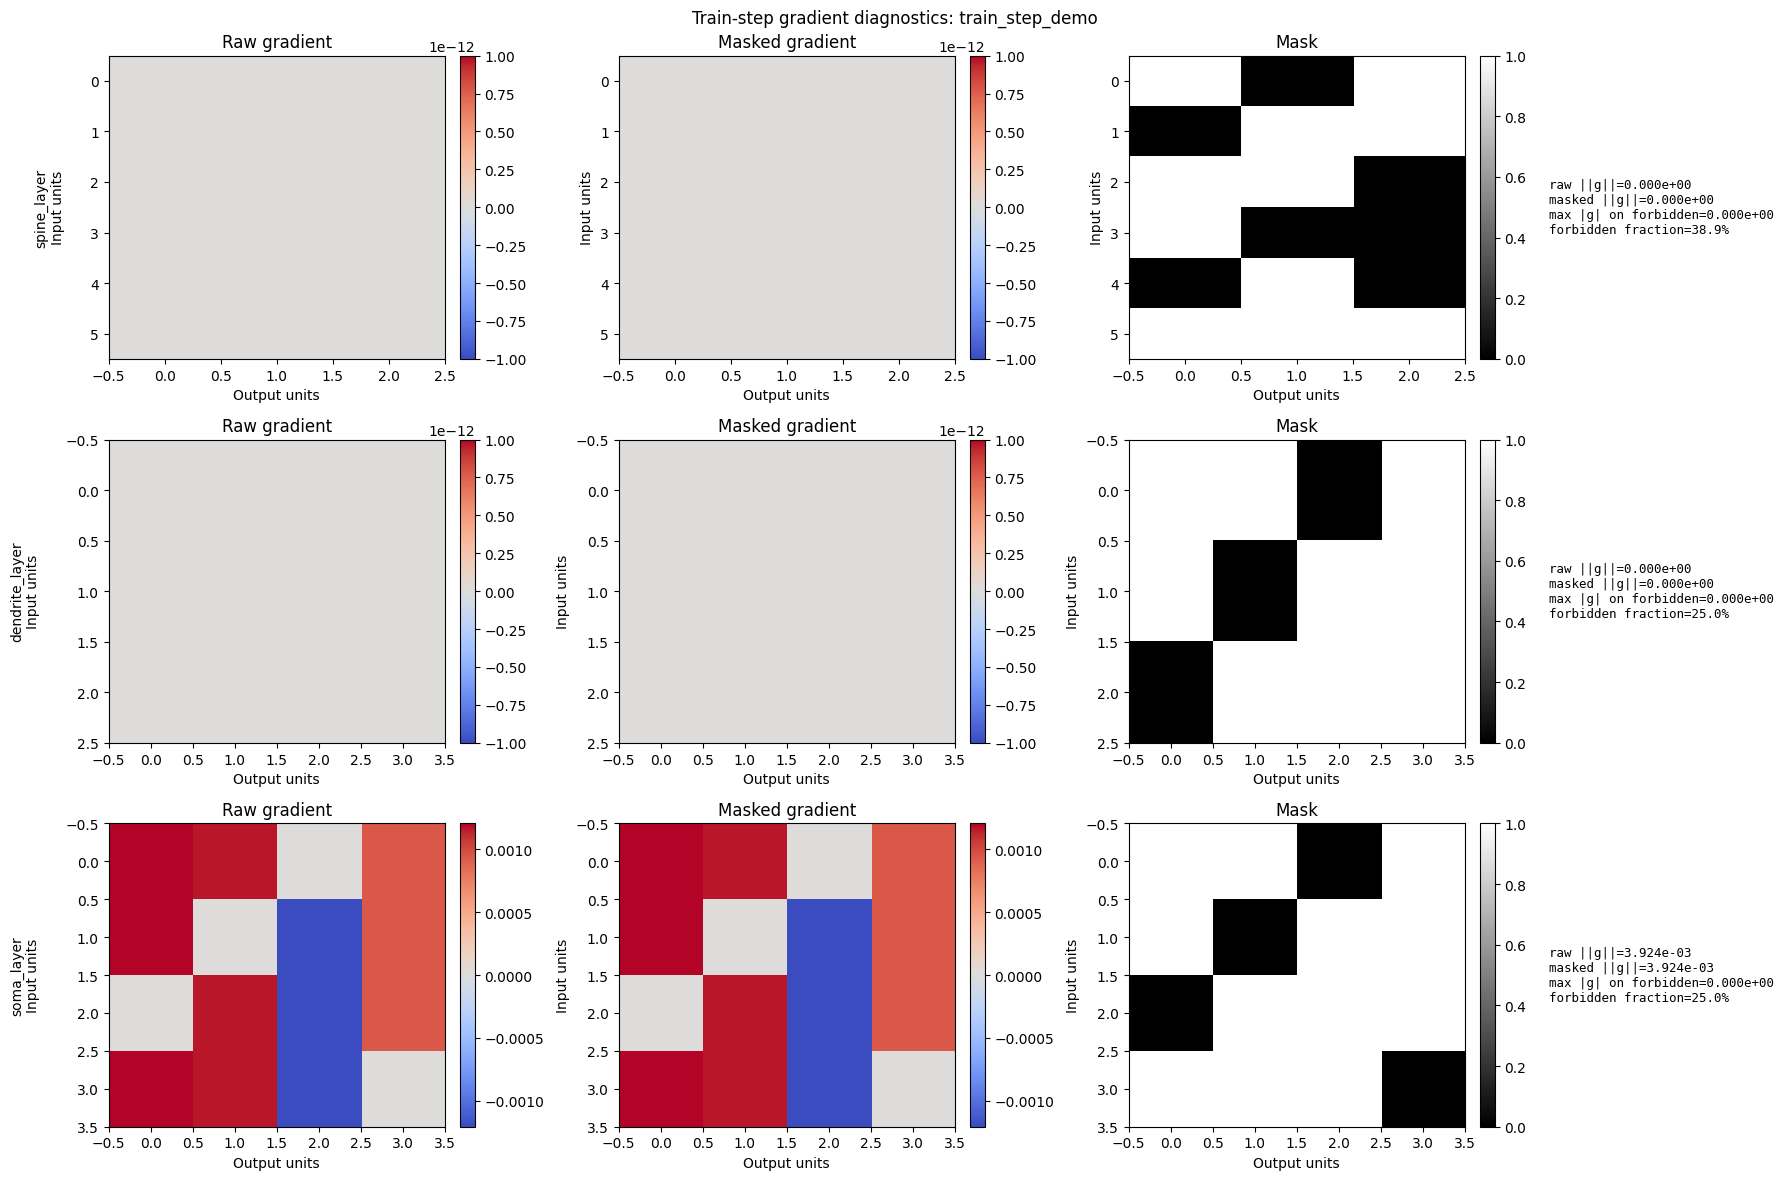

Checked train_step gradients for: train_step_demo
Max forbidden gradient magnitudes: [0.0, 0.0, 0.0]


In [15]:
if not summary_df.empty and 'constrained' in summary_df.columns and 'run_dir' in summary_df.columns:
    constrained_runs = summary_df[summary_df['constrained'] == True]
    for _, row in constrained_runs.iterrows():
        candidate_dir = row['run_dir']
        candidate_model = os.path.join(candidate_dir, 'model.keras')
        if os.path.exists(candidate_model):
            run_dir = candidate_dir
            run_name = row.get('run_name', run_name)
            model = tf.keras.models.load_model(candidate_model)
            with open(os.path.join(run_dir, 'config.json')) as f:
                run_cfg = json.load(f)
            if 'x_te' in globals() and 'y_te' in globals():
                x_batch = x_te[:8]
                y_batch = y_te[:8]
            else:
                rng = np.random.default_rng(42)
                x_batch = rng.standard_normal((8, int(run_cfg['input_dim']))).astype(np.float32)
                y_batch = rng.standard_normal((8, int(run_cfg['output_dim']))).astype(np.float32)


        diagnostics = model.inspect_train_step(x_batch, y_batch)
        plot_train_step_diagnostics(
            diagnostics,
            run_name=run_name,
            run_dir=run_dir,
            show=True,
        )

        print('Checked train_step gradients for:', run_name)
        print('Max forbidden gradient magnitudes:', [round(s['max_abs_forbidden_grad'], 6) for s in diagnostics['layer_stats']])
        break


In [17]:
import numpy as np

# 1) Helpers
def print_layer_summary(s):
    print(f"Layer: {s['layer_name']}")
    print(" mask shape:", np.array(s['mask']).shape)
    print(" unique mask values:", np.unique(s['mask']))
    print(" forbidden fraction:", 100.0 * s['forbidden_fraction'], "%")
    print(" raw ||g||:", s['raw_norm'], " masked ||g||:", s['masked_norm'])
    print(" max abs grad on forbidden:", s['max_abs_forbidden_grad'])
    print(" max abs grad on allowed:", s['max_abs_allowed_grad'])
    print("- example raw grad (slice):", np.abs(s['raw_grad']).ravel()[:10])
    print("- example masked grad (slice):", np.abs(s['masked_grad']).ravel()[:10])
    print()

# 2) Run diagnostics on a small real batch (if you have x_tr,y_tr)
try:
    xb = x_tr[:8]
    yb = y_tr[:8]
    print("=== inspect_train_step on real training batch ===")
    diag_real = model.inspect_train_step(xb, yb)
    print("loss:", diag_real["loss"])
    for s in diag_real.get("layer_stats", []):
        print_layer_summary(s)
except Exception as e:
    print("Skipping real-batch diagnostics (missing x_tr/y_tr or model):", e)

# 3) Run diagnostics on a small random non-zero batch
rng = np.random.default_rng(1)
xb = rng.standard_normal((8, model.input_dim)).astype(np.float32)
yb = rng.uniform([-90, -45], [90, 45], size=(8, 2)).astype(np.float32)
print("=== inspect_train_step on random batch ===")
diag_rand = model.inspect_train_step(xb, yb)
print("loss:", diag_rand["loss"])
for s in diag_rand.get("layer_stats", []):
    print_layer_summary(s)

# 4) Extra shape checks (kernel vs mask)
print("=== Kernel vs Mask shapes ===")
for name, layer in [("spine", model.spine_layer), ("dendrite", model.dendrite_layer), ("soma", model.soma_layer)]:
    k_shape = tuple(layer.w.shape) if hasattr(layer, "w") else None
    m_shape = tuple(layer.mask.shape) if hasattr(layer, "mask") else None
    print(f"{name}: kernel {k_shape}  mask {m_shape}")

=== inspect_train_step on real training batch ===
loss: 13319.322265625
Layer: spine_layer
 mask shape: (768, 64)
 unique mask values: [0. 1.]
 forbidden fraction: 76.5625 %
 raw ||g||: 32978.23828125  masked ||g||: 32978.23828125
 max abs grad on forbidden: 0.0
 max abs grad on allowed: 1712.9078369140625
- example raw grad (slice): [3.3614102e-36 8.3018164e-35 9.1587038e-36 3.3268417e-36 3.9530539e-36
 5.7596931e-36 3.9614844e+02 9.8483068e-37 4.3184357e-04 4.2029250e-35]
- example masked grad (slice): [3.3614102e-36 8.3018164e-35 9.1587038e-36 3.3268417e-36 3.9530539e-36
 5.7596931e-36 3.9614844e+02 9.8483068e-37 4.3184357e-04 4.2029250e-35]

Layer: dendrite_layer
 mask shape: (64, 64)
 unique mask values: [0. 1.]
 forbidden fraction: 98.4375 %
 raw ||g||: 6828.6318359375  masked ||g||: 6828.6318359375
 max abs grad on forbidden: 0.0
 max abs grad on allowed: 3654.5576171875
- example raw grad (slice): [8.6796289e-36 8.2876642e-05 2.9705421e-05 5.9909676e-06 5.4805489e-05
 5.5092129